In [79]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
import seaborn as sns

In [2]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)

# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [3]:
def inv_cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.inv(jax.scipy.linalg.toeplitz(cov0))

In [4]:
def inv_std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return jax.scipy.linalg.inv(L)

In [5]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [3]:
def compare_plot(samples, x, y_true, y_noise, compare="true"):

    y_samples = tuple(my_model(s) for s in samples)
    y_mean, y_std = jft.mean_and_std(y_samples)

    snr = np.max(np.abs(y_noise))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    rmse = np.sqrt(np.mean(diff**2))
    print(rmse)
    print(rmse/np.max(y_true))

    # plot
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1,1], "hspace":0})

    # vertical lines
    # for j in range(2):
    #      for i in range(len(x)):
    #         axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="tab:red", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="lightgray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)

    # Absolute residual (uncertainty w.r.t. residual)
    axes[2].axhline(y=0, c="lightgray", linestyle="--")

    axes[2].plot(x, abs_res, c="red")
    y_max = np.max(np.abs(abs_res))*1.2
    axes[2].set_ylim(-y_max, y_max)
    axes[2].set_ylabel("Absolute Residual")

    axes[2].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [4]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [9]:
class SignalModel(jft.Model):
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, x_grid):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.window_std_prior = window_std_prior
        self.x_grid = x_grid

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid-x0)**2/(2*sigma**2))

    def __call__(self, x):
        return self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), self.window_std_prior(x))
        # return self.cf_model(x) * self.gaussian_window(self.x_grid, 3.1e2, 30.)

# For a single channel

In [13]:
# measurement locations and data
t200 = np.load("data/time_200.npy")
d200 = np.load("data/true_trace_200.npy")
d200_noise = np.load("data/trace_200_simnoise.npy")

In [ ]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Inv_Cov = inv_cov(len(d200_noise), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d200_noise), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)

In [118]:
# likelihood
cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (1e-3, 1e-4),
    "loglogavgslope": (5., 1.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
}

x0 = jft.NormalPrior(mean=3.1e2, std=1e-10, name='mean_pos_window', shape=(1,))
sigma = jft.NormalPrior(mean=30., std=1e-21, name='std_window', shape=(1,))

shape = 200
distances = 5e-9

cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

my_model = SignalModel(cf_model, x0, sigma, t200)

lh = jft.Gaussian(data=d200_noise, noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 10
key, sampling_key = random.split(key, 2)

draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
)

kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

sample_mode = "linear_resample"

optimize_kl_args = dict(
    likelihood=lh,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

samples, state = jft.optimize_kl(**optimize_kl_args)

initial position:  {'asperity': Array(0.35431617, dtype=float64), 'flexibility': Array(-1.32866753, dtype=float64), 'fluctuations': Array(1.64462254, dtype=float64), 'loglogavgslope': Array(1.69422583, dtype=float64), 'mean_pos_window': Array([-0.9414686], dtype=float64), 'spectrum': Array([[-1.20498759e+00,  3.53187330e-02],
       [-8.42426193e-01,  5.54861298e-01],
       [ 7.33268796e-01, -1.33063824e+00],
       [-7.23535110e-01,  8.61987364e-01],
       [ 9.32204275e-01, -1.93143078e+00],
       [-8.32058272e-01,  1.80753046e-01],
       [ 1.26924950e-01, -1.58497666e+00],
       [ 5.15305190e-01,  1.59877313e+00],
       [-7.69206714e-01, -1.89439072e-01],
       [-8.82275191e-01, -9.08922447e-01],
       [ 5.46668466e-01, -1.02117710e+00],
       [-5.67507881e-01,  8.22608671e-01],
       [ 9.17575292e-01, -5.29900163e-01],
       [ 3.32403446e-02,  1.06303859e+00],
       [-2.63873351e-01, -6.47050433e-02],
       [-3.03450882e-01,  3.53067135e-01],
       [ 4.96475137e-01,  8

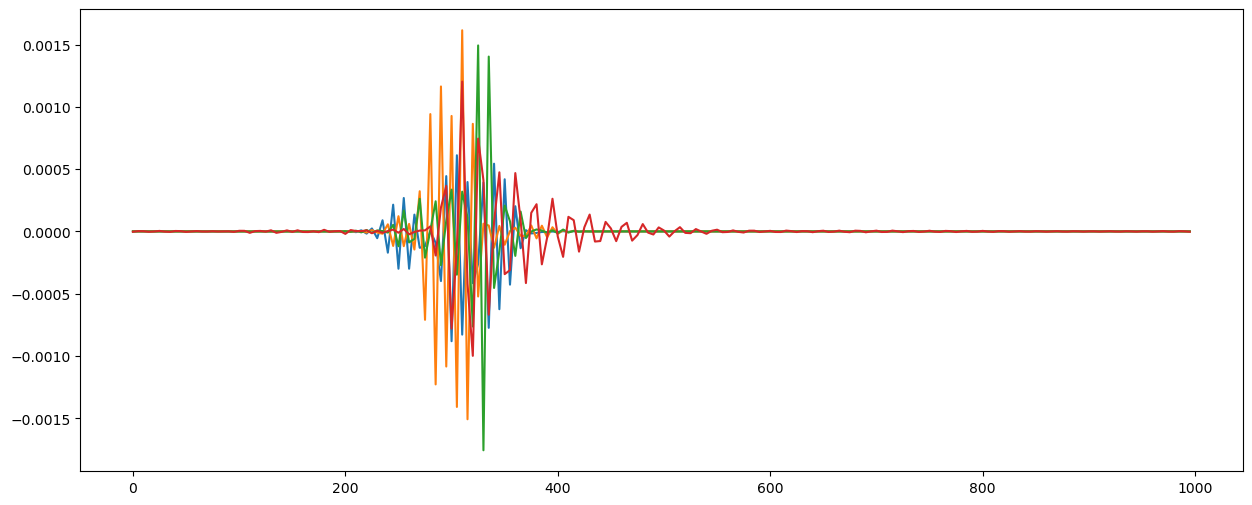

In [15]:
key, *subkeys = random.split(key, 4)
xi_samples = [jft.random_like(sk, my_model.domain) for sk in subkeys]

#  print(xi_samples[0]['spectrum'])

plt.figure(figsize=(15,6))
for i, xi in enumerate(xi_samples):
    plt.plot(t200, my_model(xi))
plt.plot(t200, d200)
plt.show()

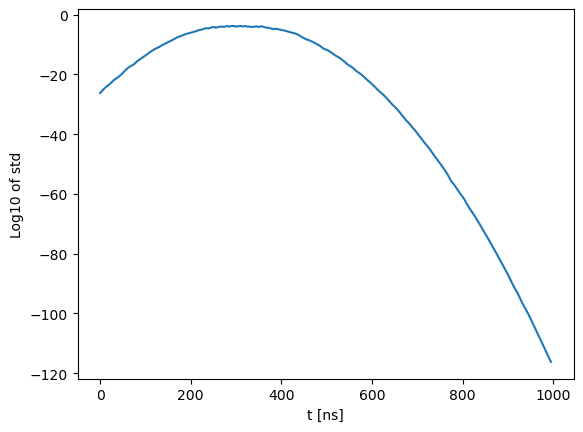

/tmp/ipykernel_227614/2216462594.py:6: RuntimeWarning: invalid value encountered in log10
  plt.plot(t200, np.log10(res[3]), label="res>0")
/tmp/ipykernel_227614/2216462594.py:7: RuntimeWarning: invalid value encountered in log10
  plt.plot(t200, np.log10(-res[3]), label="res<0")


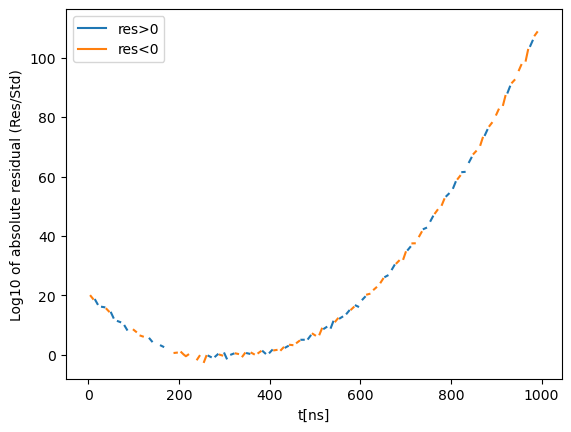

In [35]:
plt.plot(t200, np.log10(res[1]))
plt.xlabel("t [ns]")
plt.ylabel("Log10 of std")
plt.show()

plt.plot(t200, np.log10(res[3]), label="res>0")
plt.plot(t200, np.log10(-res[3]), label="res<0")
plt.legend()
plt.xlabel("t[ns]")
plt.ylabel("Log10 of absolute residual (Res/Std)")
plt.show()

# All channels

## Reconstruction

In [36]:
t200 = np.load("data/time_200.npy")
d = np.load("data/traces_allchan_200.npy")
d_true = np.load("data/true_allchan_200.npy")

In [92]:
def calc_RMSE(y_mean, y_true):
    # calculate statistical measurements
    diff = y_mean - y_true
    return np.sqrt(np.mean(diff**2)) #Root mean square

In [37]:
def show_progress(start, i, tot):
    now = time.time()
    eta = (now-start)*(tot-i)
    eta_str = f"{int(eta // 60)}m {int(eta % 60)}s"
    print(f"--- Iteration {i} | Estimated Time Remaining: {eta_str} ---", flush=True)
    return now

In [ ]:
def compare(y_mean, y_std, x, y_true, y_noise, norm_rmse, compare="true"):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[-50:]-np.mean(y_noise[-50:]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Abs_Res($t_{{peak}}$): {abs_res_peak:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [39]:
from IPython.display import clear_output
import time

# Access the internal logger instance used by optimize_kl
nifty_internal_logger = jft.optimize_kl.__globals__['logger']

# Completely stub out its info and status message logging methods
nifty_internal_logger.info = lambda *args, **kwargs: None

In [ ]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Inv_Cov = inv_cov(len(d200_noise), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d200_noise), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)

In [ ]:
# likelihood
tot = len(d)

n=0
sus = []
means = []
stds = []
rmses = []
norm_rmses = []
now = time.time()

for i in range(tot):

    clear_output(wait=True)
    now = show_progress(now, i, tot)

    # Print the ongoing history of found anomalies so far
    # if sus:
    #     print("\n[Anomalies Found So Far]:")
    #     for log_entry in sus:
    #         print(log_entry)
    #     print("-" * 30 + "\n")
    
    jax.clear_caches()
    cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (5e-4, 8e-4),
    "loglogavgslope": (7., 2.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
    }

    x0 = jft.NormalPrior(mean=3.1e2, std=50, name='mean_pos_window', shape=(1,))
    sigma = jft.NormalPrior(mean=30., std=30, name='std_window', shape=(1,))

    shape = 200
    distances = 5e-9

    cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
    my_model = SignalModel(cf_model, x0, sigma, t200)

    lh = jft.Gaussian(data=d[i], noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

    key, subkey = random.split(key, 2)
    init_pos = jft.Vector(lh.init(subkey))
    n_vi_iterations = 6
    n_samples = 4

    key, sampling_key = random.split(key, 2)

    draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
    )

    kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

    sample_mode = "linear_resample"

    optimize_kl_args = dict(
        likelihood=lh,
        position_or_samples=init_pos,
        n_total_iterations=n_vi_iterations,
        n_samples=n_samples,
        key=sampling_key,
        draw_linear_kwargs=draw_linear_kwargs,
        kl_kwargs=kl_kwargs,
        sample_mode=sample_mode,
        )

    s, state = jft.optimize_kl(**optimize_kl_args)

    y_samples = tuple(my_model(s) for s in s)
    y_mean, y_std = jft.mean_and_std(y_samples)
    means.append(y_mean)
    stds.append(y_std)

    rmse=calc_RMSE(y_mean, d_true[i])
    norm_rmse = rmse/np.max(np.abs(d_true[i])) 
    rmses.append(rmse)
    norm_rmses.append(norm_rmse)

    if norm_rmse > 0.1:
        # sus.append(f"IDX {i}: RMSE/max_amp={norm_rmse:.4f}")
        n += 1

clear_output(wait=True)
print("=== All Channels complete ===")
print(f"Total Suspicious Indices: {n}/{tot}\n")
# if sus:
#     print("Full Log of Anomalies:")
#     for log_entry in sus:
#         print(f"  * {log_entry}")

means = np.array(means)
stds = np.array(stds)
rmses = np.array(rmses)
norm_rmses = np.array(norm_rmses)

=== All Channels complete ===
Total Suspicious Indices: 1338/1344



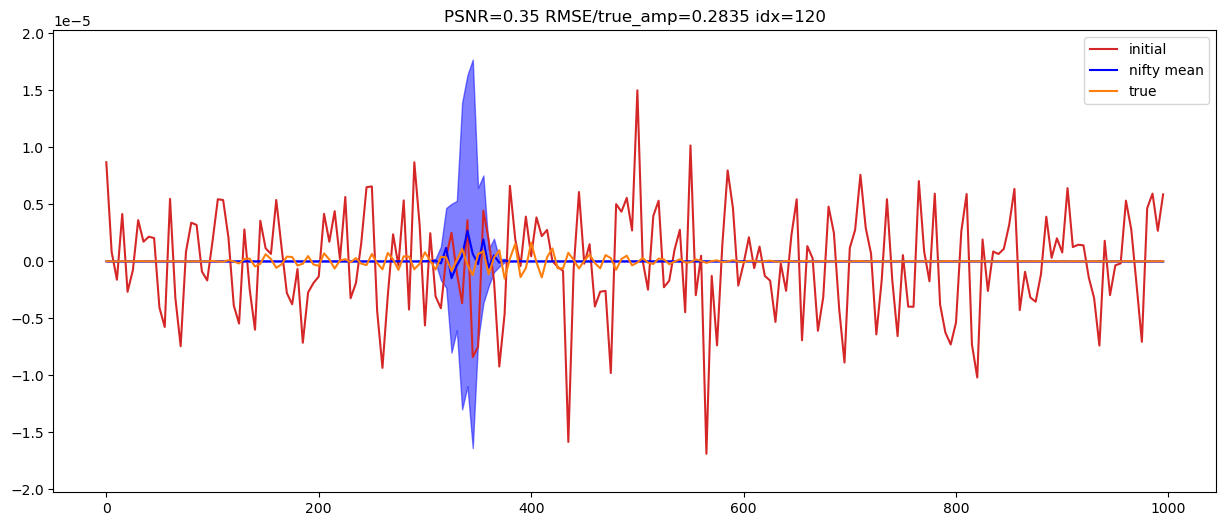

In [189]:
idx= np.random.randint(0,138)
snr = np.max(np.abs(d_true[idx]))/np.sqrt(np.mean(np.square(d[idx][:-50]-np.mean(d[idx][:-50]))))
plt.figure(figsize=(15, 6))
plt.plot(t200, d[idx], label="initial", c="tab:red")
plt.fill_between(t200, means[idx]-stds[idx], means[idx]+stds[idx], color="blue", alpha=0.5)
plt.plot(t200, means[idx], label="nifty mean", c="blue")
plt.plot(t200, d_true[idx], label="true", c="tab:orange")
plt.legend()
ymax = np.max(np.abs(d[idx]))*1.2
plt.ylim(-ymax, ymax)
plt.title(f"PSNR={snr:.2f} RMSE/true_amp={norm_rmses[idx]:.4f} idx={idx}")
plt.show()

133


/tmp/ipykernel_227614/376632903.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


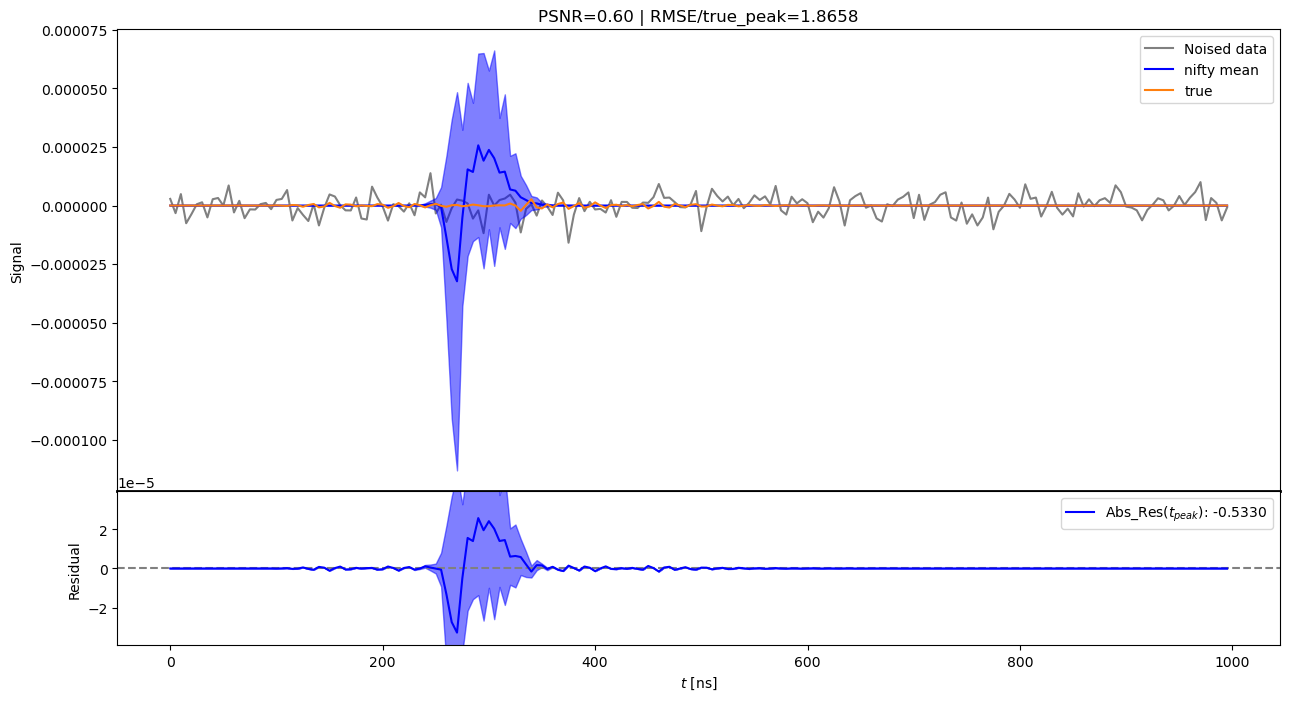

In [292]:
idx= np.random.randint(0,len(means))
print(idx)
res = compare(means[idx], stds[idx], t200, d_true[idx], d[idx], norm_rmses[idx])

In [310]:
np.save("results/allchan1/means.npy", means)
np.save("results/allchan1/stds.npy", stds)
np.save("results/allchan1/rmses.npy", rmses)
np.save("results/allchan1/norm_rmses.npy", norm_rmses)

## Analysis

In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
import seaborn as sns

In [37]:
def compare(y_mean, y_std, x, y_true, y_noise, norm_rmse, compare="true"):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[-50:]-np.mean(y_noise[-50:]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Abs_Res($t_{{peak}}$): {abs_res_peak:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [7]:
means = np.load("results/allchan1/means.npy")
stds = np.load("results/allchan1/stds.npy")
rmses = np.load("results/allchan1/rmses.npy")
norm_rmses = np.load("results/allchan1/norm_rmses.npy")
t200 = np.load("data/time_200.npy")
d = np.load("data/traces_allchan_200.npy")
d_true = np.load("data/true_allchan_200.npy")

Check ones that had good norm_rmse?

In [11]:
good_cond = np.where(norm_rmses < 0.1)
good_means = means[good_cond]
good_stds = stds[good_cond]
good_rmses = rmses[good_cond]
good_norm_rmses = norm_rmses[good_cond]
good_d = d[good_cond]
good_d_true = d_true[good_cond]

In [12]:
len(good_means)

5

/tmp/ipykernel_353046/499695271.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


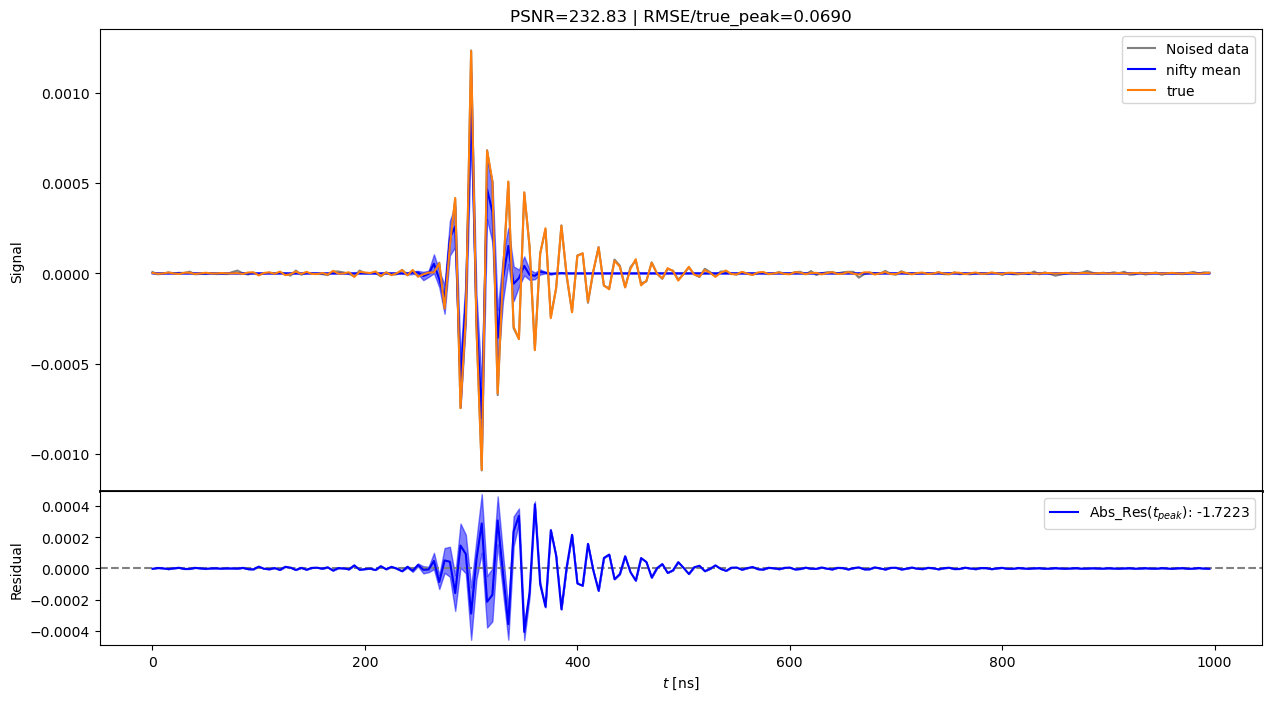

In [76]:
idx = 0
res = compare(good_means[idx], good_stds[idx], t200, good_d_true[idx], good_d[idx], good_norm_rmses[idx])

Let's calculate PSNR and UWR

In [68]:
# Calculate SNR and UWR
def snr_uwr(y_true, y_noise, y_mean, y_std):
    snr = np.max(np.abs(y_true), axis=1)/np.sqrt(np.mean(np.square(y_noise[:, -50:]), axis=1))
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.arange(len(abs_res)), np.argmax(np.abs(y_true), axis=1)]

    return snr, abs_res_peak

In [69]:
snr, uwr = snr_uwr(d_true, d, means, stds)

/tmp/ipykernel_353046/3488436193.py:5: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


Histogram of SNR. I am surprised how large they are.

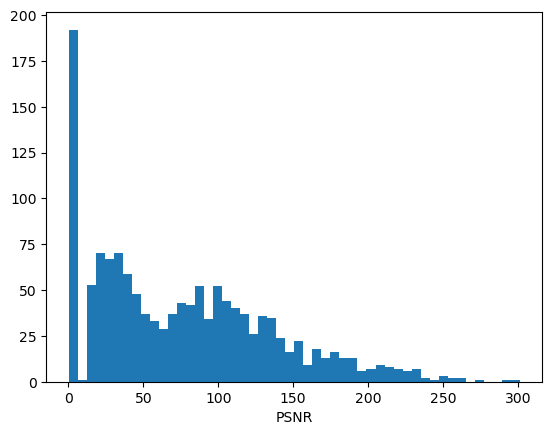

In [89]:
plt.hist(snr, bins = 50)
plt.xlabel("PSNR")
plt.show()

Could not generate histogram of UWR(t_peak)^2 ~ chi^2 because there are values that are infinite. I suspect that it is because too tiny std. 

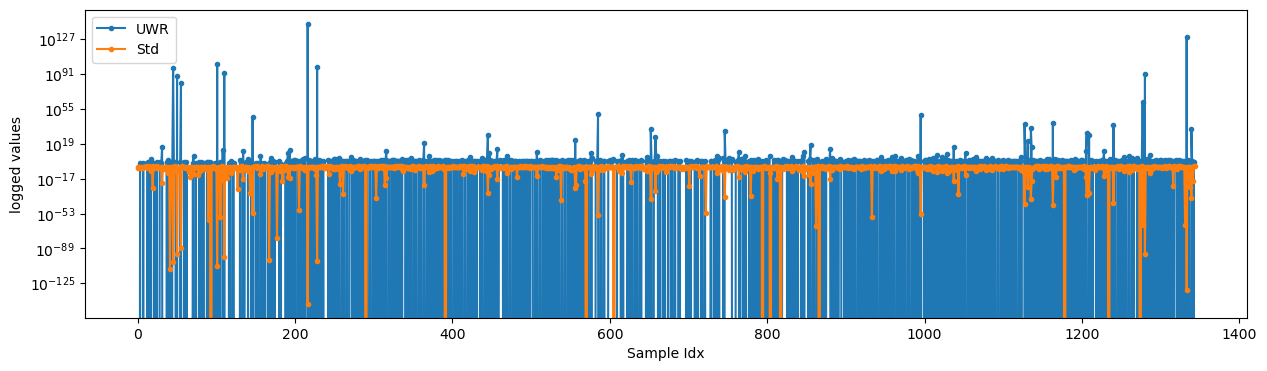

In [91]:
plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(uwr)), uwr, marker=".", label="UWR")
plt.plot(np.arange(len(stds)), stds[np.arange(len(stds)), np.argmax(np.abs(d_true), axis=1)], marker=".", label="Std")
plt.legend()
plt.xlabel("Sample Idx")
plt.ylabel("logged values")
plt.yscale("log")
plt.show()

In [87]:
def compare_samples(idx):
    return compare(means[idx], stds[idx], t200, d_true[idx], d[idx], norm_rmses[idx])

Let's see what kind of trace has such a terrible UWR

/tmp/ipykernel_353046/499695271.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


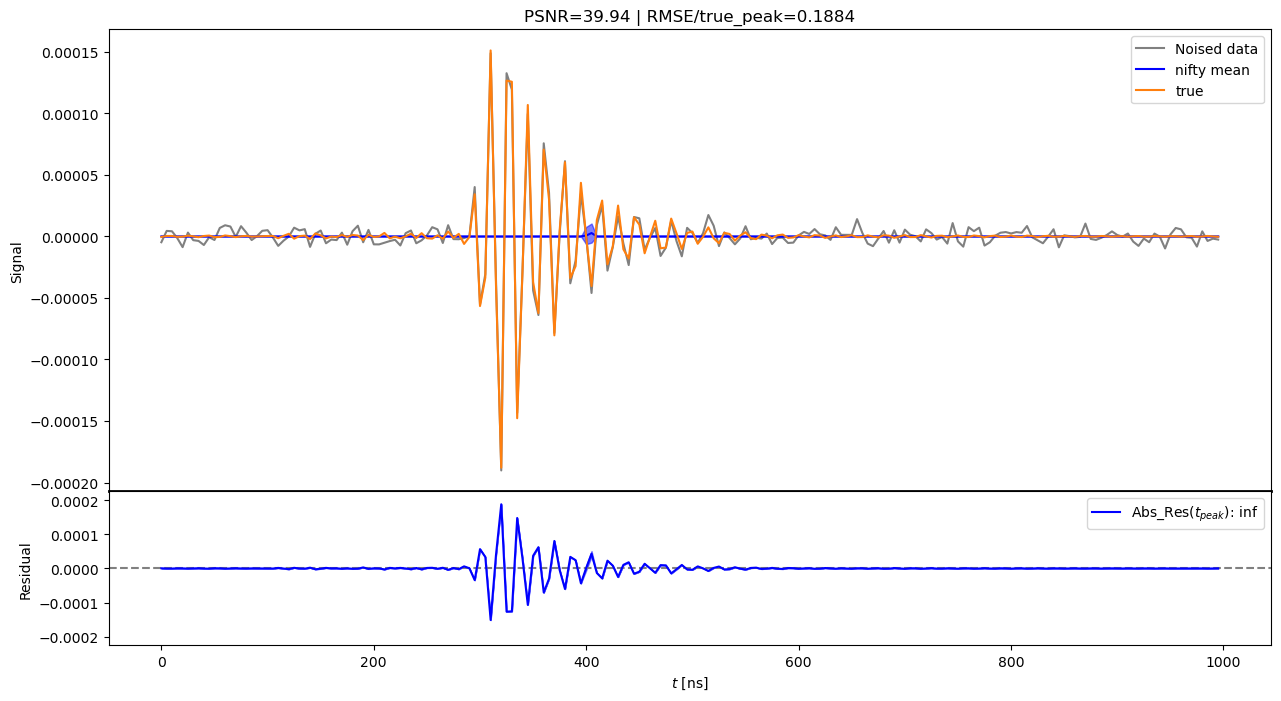

In [88]:
res = compare_samples(np.argmax(uwr))

Just in case I will see the scatter plot of PSNR vs chi^2

In [112]:
np.max(uwr[np.where(uwr < 1e90)])

np.float64(8.436879715451005e+88)

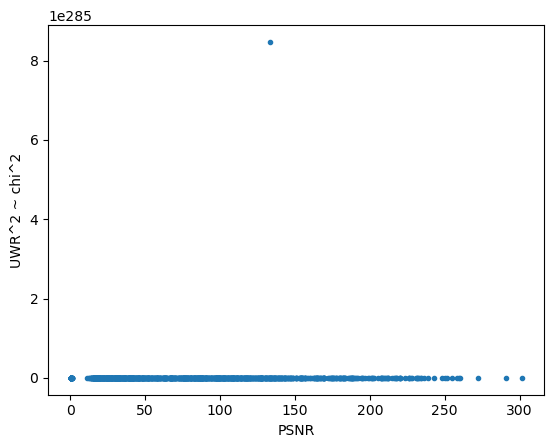

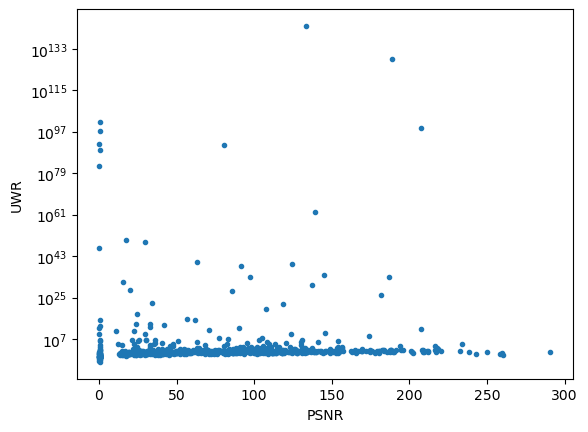

In [119]:
plt.scatter(snr, uwr**2, marker=".")
plt.xlabel("PSNR")
plt.ylabel("UWR^2 ~ chi^2")
plt.show()
plt.close()

finite_uwr = uwr[np.where(uwr!=np.inf)]
finite_snr = snr[np.where(uwr!=np.inf)]

f0_uwr = finite_uwr[np.where(finite_uwr > 0)]
f0_snr = finite_snr[np.where(finite_uwr > 0)]

plt.scatter(f0_snr, f0_uwr, marker=".")
plt.xlabel("PSNR")
plt.ylabel("UWR")
plt.yscale("log")
plt.show()

# Generate noise from Cov

## Defining Functions

In [5]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import seaborn as sns

In [6]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)

# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [7]:
def inv_cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.inv(jax.scipy.linalg.toeplitz(cov0))

In [8]:
def inv_std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return jax.scipy.linalg.inv(L)

In [9]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [10]:
def std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return L

In [11]:
def compare_plot(samples, x, y_true, y_noise, compare="true"):

    y_samples = tuple(my_model(s) for s in samples)
    y_mean, y_std = jft.mean_and_std(y_samples)

    snr = np.max(np.abs(y_noise))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    rmse = np.sqrt(np.mean(diff**2))
    print(rmse)
    print(rmse/np.max(y_true))

    # plot
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1,1], "hspace":0})

    # vertical lines
    # for j in range(2):
    #      for i in range(len(x)):
    #         axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="tab:red", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="lightgray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)

    # Absolute residual (uncertainty w.r.t. residual)
    axes[2].axhline(y=0, c="lightgray", linestyle="--")

    axes[2].plot(x, abs_res, c="red")
    y_max = np.max(np.abs(abs_res))*1.2
    axes[2].set_ylim(-y_max, y_max)
    axes[2].set_ylabel("Absolute Residual")

    axes[2].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [12]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [13]:
class SignalModel(jft.Model):
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, x_grid):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.window_std_prior = window_std_prior
        self.x_grid = x_grid

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid-x0)**2/(2*sigma**2))

    def __call__(self, x):
        return self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), self.window_std_prior(x))
        # return self.cf_model(x) * self.gaussian_window(self.x_grid, 3.1e2, 30.)

In [14]:
def calc_RMSE(y_mean, y_true):
    # calculate statistical measurements
    diff = y_mean - y_true
    return np.sqrt(np.mean(diff**2)) #Root mean square

In [15]:
def show_progress(start, i, tot):
    now = time.time()
    eta = (now-start)*(tot-i)
    eta_str = f"{int(eta // 60)}m {int(eta % 60)}s"
    print(f"--- Iteration {i} | Estimated Time Remaining: {eta_str} ---", flush=True)
    return now

In [16]:
def compare(y_mean, y_std, x, y_true, y_noise, norm_rmse, compare="true"):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Res($t_{{peak}}$): {abs_res_peak:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [17]:
from IPython.display import clear_output
import time

# Access the internal logger instance used by optimize_kl
nifty_internal_logger = jft.optimize_kl.__globals__['logger']

# Completely stub out its info and status message logging methods
nifty_internal_logger.info = lambda *args, **kwargs: None

In [18]:
t200 = np.load("data/time_200.npy")
# d200 = np.load("data/true_trace_200.npy")
# d200_noise = np.load("data/trace_200_simnoise.npy")

## LOFAR 
### Generate Mock Signals

In [31]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Inv_Cov = inv_cov(len(t200), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(t200), A, omega0, gamma, p, C)
Cov = cov(len(t200), A, omega0, gamma, p, C)
Std = std(len(t200), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)
noise_cov = lambda x: jnp.matmul(Cov, x)
noise_std = lambda x: jnp.matmul(Std, x)

In [16]:
cf_kwargs = {
"offset_mean": 0,
"offset_std": (1.71e-4, 1e-5),
"fluctuations": (5e-4, 8e-4),
"loglogavgslope": (7., 2.5),
"flexibility": (1.0, 1.0),
"asperity": (1.0e-8, 1.0e-8),
"prefix": "",
}

x0 = jft.NormalPrior(mean=3.1e2, std=50, name='mean_pos_window', shape=(1,))
sigma = jft.NormalPrior(mean=30., std=30, name='std_window', shape=(1,))

shape = 200
distances = 5e-9

cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
my_model = SignalModel(cf_model, x0, sigma, t200)

In [32]:
signal_options = []
data_options = []

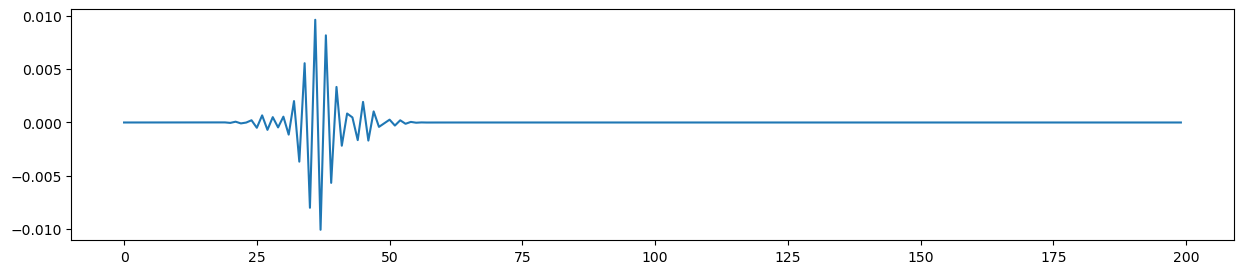

In [391]:
key, *subkeys = random.split(key, 4)
xi_samples = [jft.random_like(sk, my_model.domain) for sk in subkeys]

mock_signal = my_model(xi_samples[0])

noise = noise_std(jft.random_like(subkeys[1], my_model.target))

mock_data = mock_signal + noise

plt.figure(figsize=(15, 3))
plt.plot(mock_signal)
# plt.plot(mock_data)

In [392]:
signal_options.append(mock_signal)
data_options.append(mock_data)

In [394]:
len(signal_options)

20

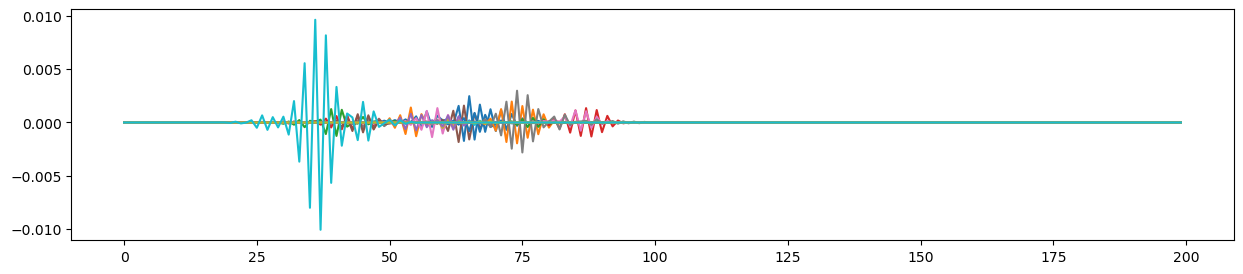

In [393]:
plt.figure(figsize=(15, 3))
for signal in signal_options:
    plt.plot(signal)
plt.show()

In [535]:
del signal_options[1]
del data_options[1]

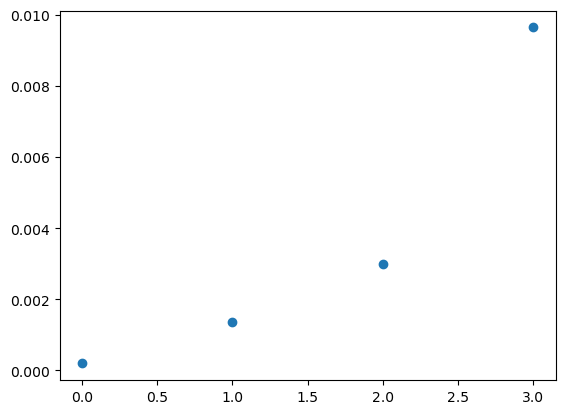

In [536]:
plt.scatter(np.arange(len(signal_options)), np.max(np.array(signal_options), axis=1))
plt.show()

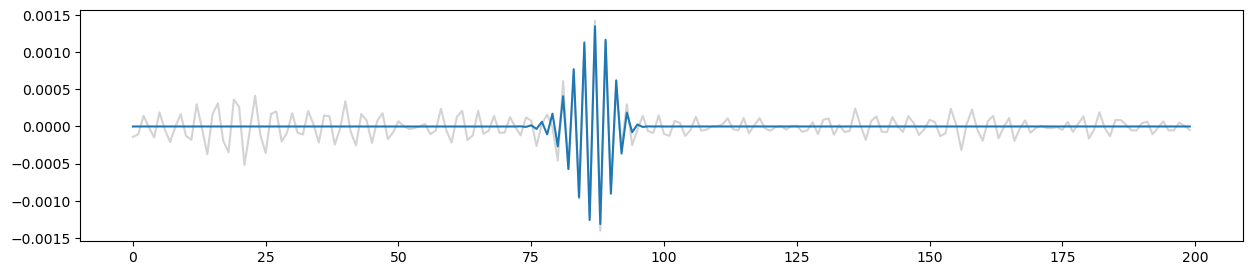

In [537]:
idx = 1
plt.figure(figsize=(15,3))
plt.plot(data_options[idx], c="lightgray")
plt.plot(signal_options[idx])
plt.show()

In [538]:
np.save("data/mock_signal1.npy", np.array(signal_options))
np.save("data/mock_data1.npy", np.array(data_options))

### With Non-diagonal

In [539]:
d = np.load("data/mock_data1.npy")
d_true = np.load("data/mock_signal1.npy")

In [32]:
# likelihood
tot = len(d)

n=0
sus = []
means = []
stds = []
rmses = []
norm_rmses = []
now = time.time()

for i in range(tot):

    clear_output(wait=True)
    now = show_progress(now, i, tot)

    # Print the ongoing history of found anomalies so far
    # if sus:
    #     print("\n[Anomalies Found So Far]:")
    #     for log_entry in sus:
    #         print(log_entry)
    #     print("-" * 30 + "\n")
    
    jax.clear_caches()
    cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (5e-4, 8e-4),
    "loglogavgslope": (7., 2.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
    }

    x0 = jft.NormalPrior(mean=3.1e2, std=50, name='mean_pos_window', shape=(1,))
    sigma = jft.NormalPrior(mean=30., std=30, name='std_window', shape=(1,))

    shape = 200
    distances = 5e-9

    cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
    my_model = SignalModel(cf_model, x0, sigma, t200)

    lh = jft.Gaussian(data=d[i], noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

    key, subkey = random.split(key, 2)
    init_pos = jft.Vector(lh.init(subkey))
    n_vi_iterations = 6
    n_samples = 4

    key, sampling_key = random.split(key, 2)

    draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
    )

    kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

    sample_mode = "linear_resample"

    optimize_kl_args = dict(
        likelihood=lh,
        position_or_samples=init_pos,
        n_total_iterations=n_vi_iterations,
        n_samples=n_samples,
        key=sampling_key,
        draw_linear_kwargs=draw_linear_kwargs,
        kl_kwargs=kl_kwargs,
        sample_mode=sample_mode,
        )

    s, state = jft.optimize_kl(**optimize_kl_args)

    y_samples = tuple(my_model(s) for s in s)
    y_mean, y_std = jft.mean_and_std(y_samples)
    means.append(y_mean)
    stds.append(y_std)

    rmse=calc_RMSE(y_mean, d_true[i])
    norm_rmse = rmse/np.max(np.abs(d_true[i])) 
    rmses.append(rmse)
    norm_rmses.append(norm_rmse)

    if norm_rmse > 0.1:
        # sus.append(f"IDX {i}: RMSE/max_amp={norm_rmse:.4f}")
        n += 1

clear_output(wait=True)
print("=== All Channels complete ===")
print(f"Total Suspicious Indices: {n}/{tot}\n")
# if sus:
#     print("Full Log of Anomalies:")
#     for log_entry in sus:
#         print(f"  * {log_entry}")

means = np.array(means)
stds = np.array(stds)
rmses = np.array(rmses)
norm_rmses = np.array(norm_rmses)

=== All Channels complete ===
Total Suspicious Indices: 0/4



/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/2259919039.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


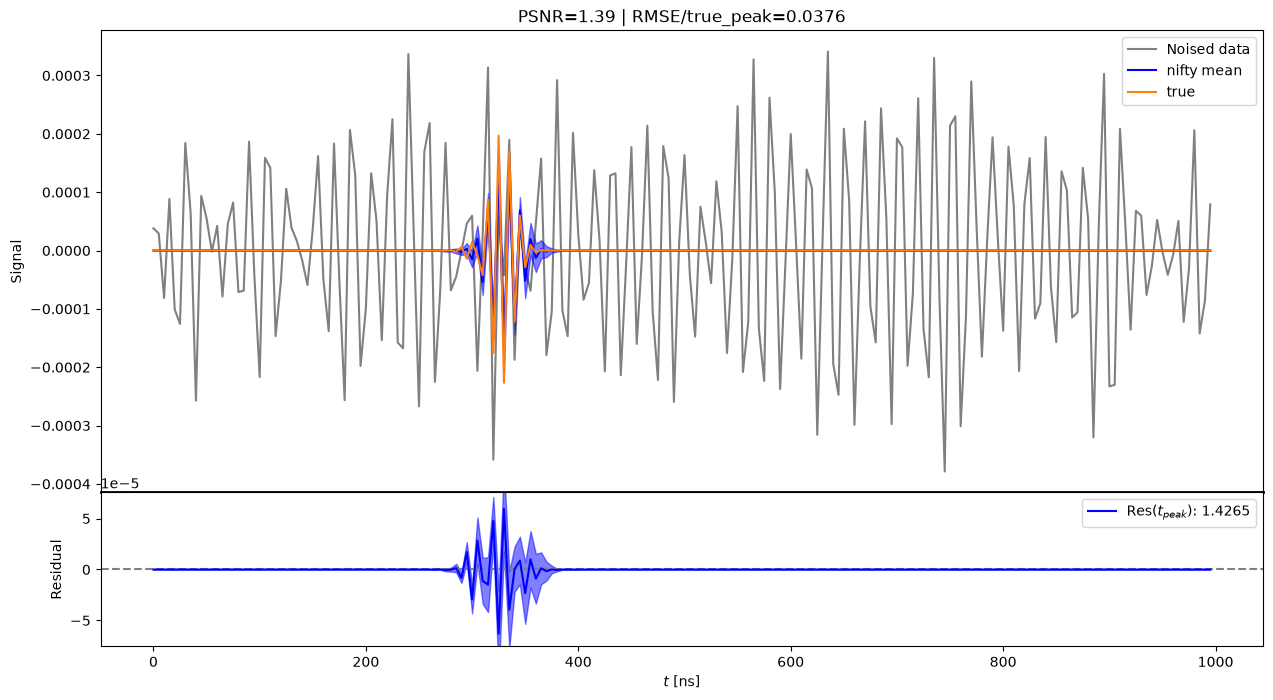

In [33]:
idx= 0
res = compare(means[idx], stds[idx], t200, d_true[idx], d[idx], norm_rmses[idx])

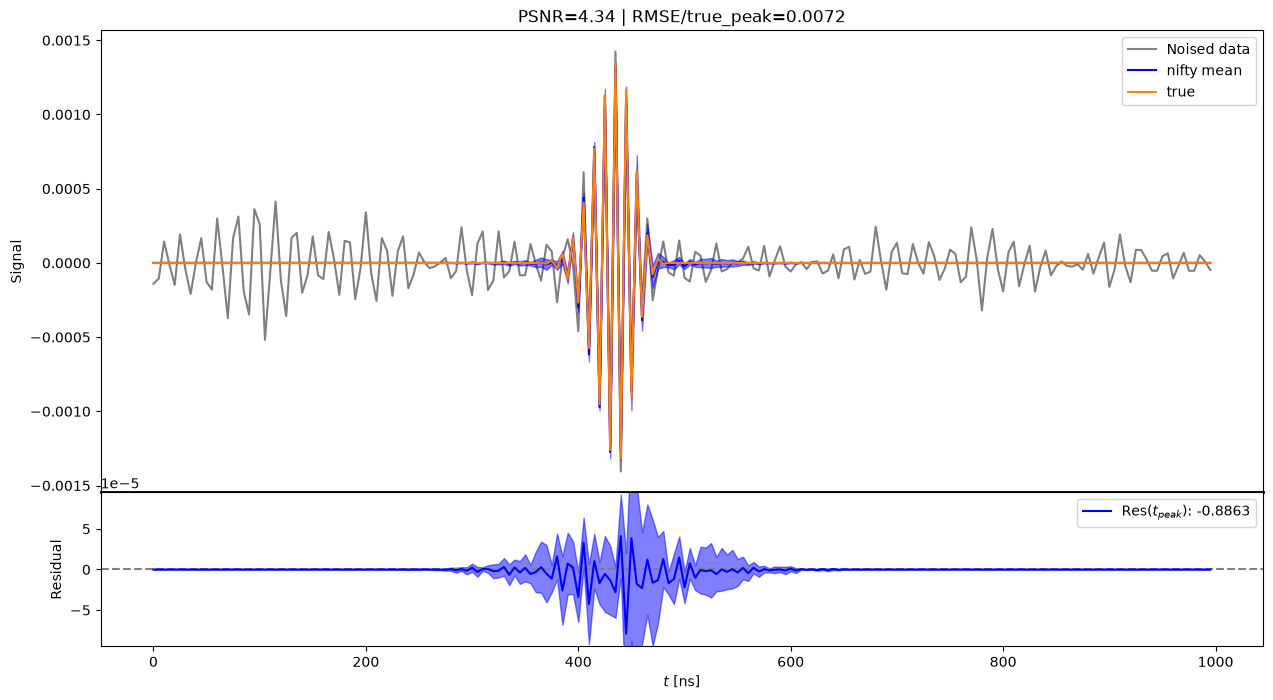

In [34]:
idx= 1
res = compare(means[idx], stds[idx], t200, d_true[idx], d[idx], norm_rmses[idx])

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/2259919039.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


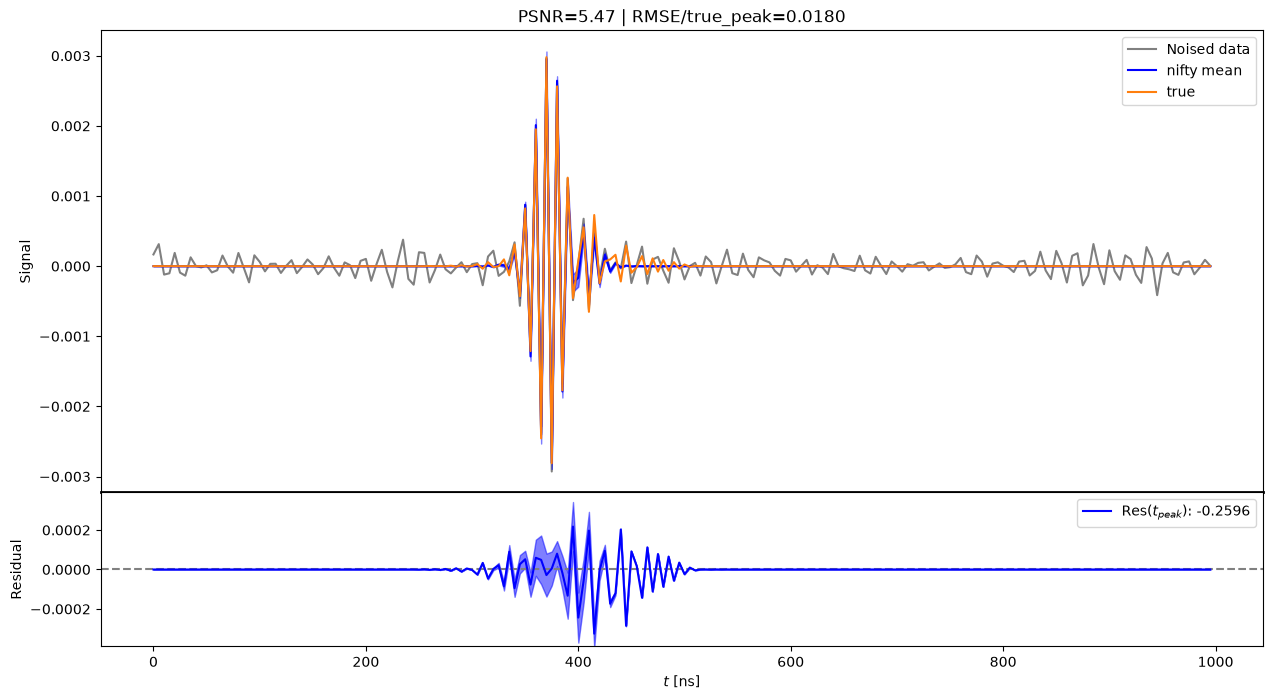

In [35]:
idx= 2
res = compare(means[idx], stds[idx], t200, d_true[idx], d[idx], norm_rmses[idx])

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/2259919039.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


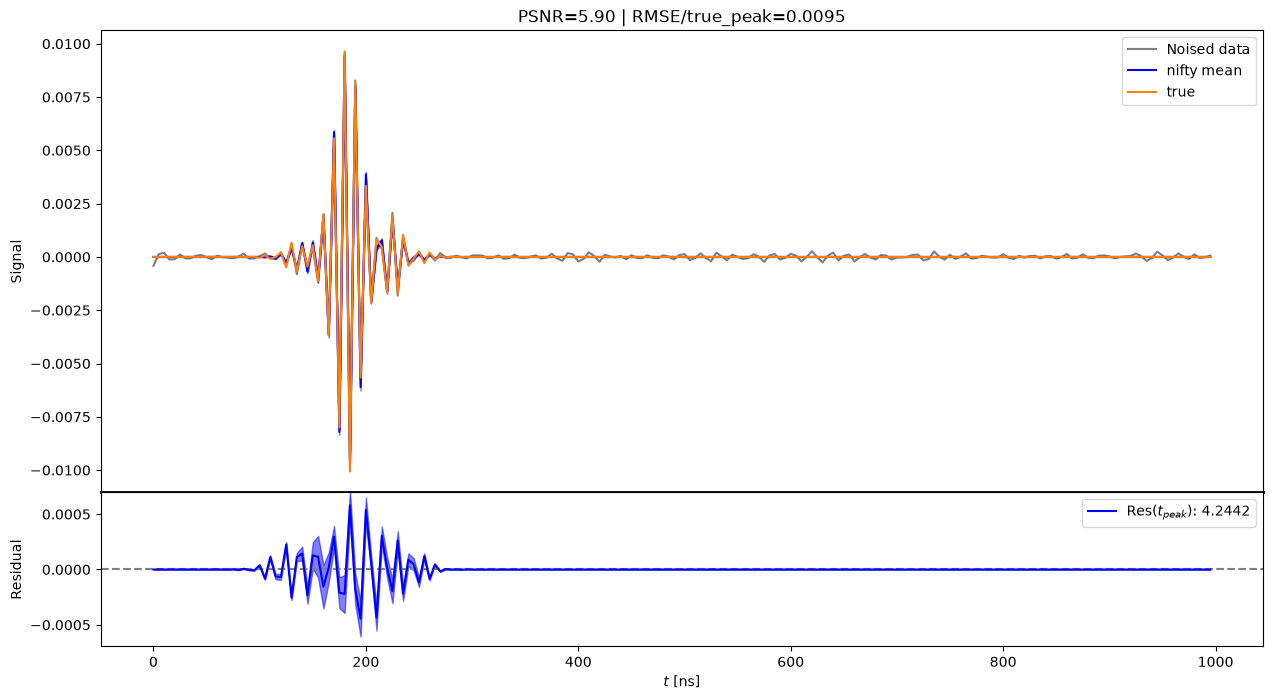

In [36]:
idx= 3
res = compare(means[idx], stds[idx], t200, d_true[idx], d[idx], norm_rmses[idx])

In [37]:
np.save("results/mock1/means.npy", means)
np.save("results/mock1/stds.npy", stds)
np.save("results/mock1/rmses.npy", rmses)
np.save("results/mock1/norm_rmses.npy", norm_rmses)

In [38]:
def snr_uwr_peak(y_true, y_noise, y_mean, y_std):
    snr = np.max(np.abs(y_true), axis=1)/np.sqrt(np.mean(np.square(y_noise[:, -50:]), axis=1))
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.arange(len(abs_res)), np.argmax(np.abs(y_true), axis=1)]

    return snr, abs_res_peak

In [39]:
def snr_uwr(y_true, y_noise, y_mean, y_std):
    snr = np.max(np.abs(y_true), axis=1)/np.sqrt(np.mean(np.square(y_noise[:, -50:]), axis=1))
    diff = y_mean - y_true
    abs_res = diff/y_std

    return snr, np.mean(abs_res, axis=1), np.std(abs_res, axis=1)/np.sqrt(len(y_mean))

In [40]:
snr, uwr_peak = snr_uwr_peak(d_true, d, means, stds)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/1738862909.py:4: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


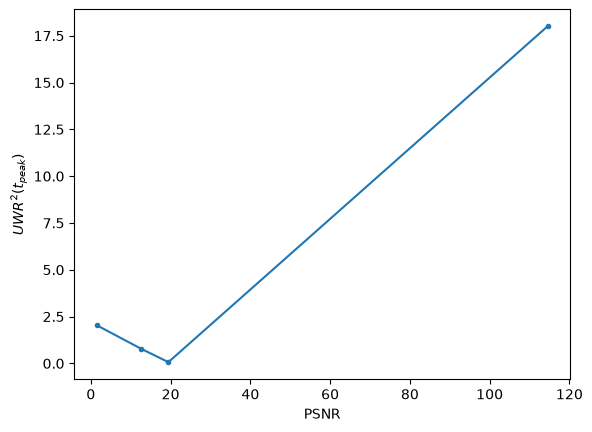

In [41]:
plt.plot(snr, uwr_peak**2, marker=".")
plt.xlabel("PSNR")
plt.ylabel(r"$UWR^2(t_{peak})$")
plt.show()

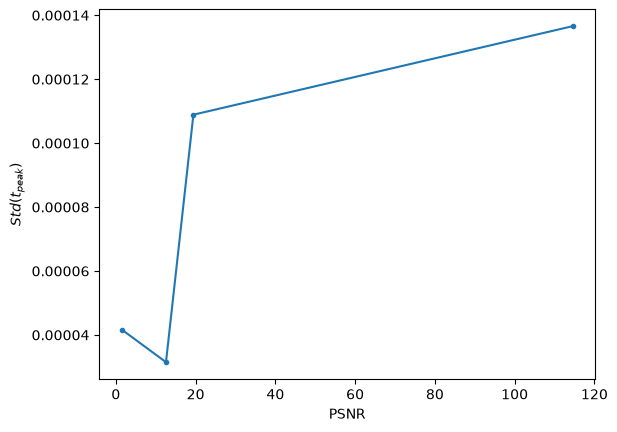

In [43]:
stds_peak = stds[np.arange(len(stds)), np.argmax(np.abs(d_true), axis=1)]

plt.plot(snr, stds_peak, marker=".")
plt.xlabel("PSNR")
plt.ylabel(r"$Std(t_{peak})$")
plt.show()

In [45]:
def calc_RMSE_err(y_mean, y_true, y_std):
    # calculate statistical measurements
    diff = y_mean - y_true
    R = np.sqrt(np.mean(diff** 2, axis=1)) #Root mean square

    N = y_mean.shape[1]

    R_err = (1/N * R) * np.sqrt(np.sum(diff**2 * y_std**2, axis=1))
    return R, R_err

Calculating Error Propagation for RMSE:

Let values of posterior distribution be $\bold{\mu} = (\mu_i)$ for each $i$ th bin, up to $N$ .

The mean posterior is $\bar{\bold{y}} = (\bar{y}_i)$, and 
$$ \mu_i = \bar{\mu}_i + \delta \mu_i $$
where $\delta y_i$ is a signed fluctuation of the mean posterior at each bin.

The standard deviation $\sigma_i$ for posterior distribution at each bin is then defined as
$$ \sigma_i^2 = \langle (\delta y_i) \rangle $$

On the other hand, RMSE is calculated by
$$ R = \sqrt{\frac{\sum_i (\mu_i-x_i)^2}{N}}$$
where $x_i$ is the true value at each bin.

The error propagation tells us that
$$\delta  R = \frac{\partial R}{\partial \mu_i} \delta \mu_i$$
Evaluating the derivative:
$$
\begin{align}
    \frac{\partial R}{\partial \mu_i} &= \frac{\partial}{\partial \mu_i} \left[ \frac{(\mu_i - x_i)^2}{N} \right] ^{1/2}\\
    & = \frac{1}{2} \left[ \frac{(\mu_i - x_i)^2}{N} \right]^{-1/2} \frac{\partial} {\partial \mu_i} \left[ \frac{(\mu_i - x_i)^2}{N} \right] \\
    & = \frac{1}{2R} \frac{\partial}{\partial \mu_i} \left[ \frac{(\mu_i - x_i)^2}{N} \right] \\
    & = \frac{1}{2R} \frac{2}{N} (\mu_i - x_i \frac{\partial}{\partial \mu_i (\mu_i - x_i)}) \\
    & = \frac{\mu_i - x_i} {NR}
 \end{align}
 $$

Hence,
$$ \delta R = \sum_i \frac{\bar{\mu_i} -x_i} {NR} \delta \mu_i $$

Therefore,
$$
\begin{align}
    \sigma_R^2 &= \langle (\delta R)^2 \rangle \\
    &= \frac{1}{N^2 R^2} \langle \sum_i (\bar{\mu_i} - x_i)\delta \mu \sum_j (\bar{\mu_j} - x_j) \delta \mu_j \rangle \\
    &= \frac{1}{N^2 R^2} \sum_{i, j} (\bar{\mu_i} - x_i) (\bar{\mu_j} - x_j) \langle \delta \mu_i \delta \mu_j \rangle \\
    &= \frac{1}{N^2 R^2} \sum_{i, j} (\bar{\mu_i} - x_i) (\bar{\mu_j} - x_j) Cov_{i, j}
\end{align}
$$
And, if we assume that each bin is uncorrelated so that $Cov_{i, j}$ is diagonal,
$$ \sigma_R^2 = \frac{1}{N^2 R^2} \sum_i (\bar{\mu_i} - x_i)^2 \sigma_i^2 $$

Then, the propaged uncertainty should be the square root of the above expression, which I defined in the `calc_RMSE_err` function.

In [46]:
rmse, rmse_err = calc_RMSE_err(means, d_true, stds)

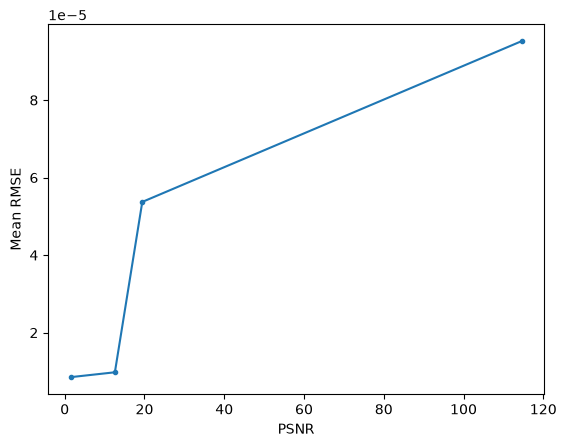

In [47]:
plt.errorbar(snr, rmse, rmse_err, marker=".")
plt.xlabel("PSNR")
plt.ylabel("Mean RMSE")
plt.show()

### With diagonal

In [48]:
d = np.load("data/mock_data1.npy")
d_true = np.load("data/mock_signal1.npy")

In [107]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Cov = cov(len(t200), A, omega0, gamma, p, C)
Cov_diag = jnp.diag(jnp.diag(Cov))

Inv_Cov = jax.scipy.linalg.inv(Cov_diag)
Inv_Std = jax.scipy.linalg.inv(jax.scipy.linalg.cholesky(Cov_diag))

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)

In [108]:
# likelihood
tot = len(d)

n=0
sus = []
means_diag = []
stds_diag = []
rmses_diag = []
norm_rmses_diag = []
now = time.time()

for i in range(tot):

    clear_output(wait=True)
    now = show_progress(now, i, tot)

    # Print the ongoing history of found anomalies so far
    # if sus:
    #     print("\n[Anomalies Found So Far]:")
    #     for log_entry in sus:
    #         print(log_entry)
    #     print("-" * 30 + "\n")
    
    jax.clear_caches()
    cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (5e-4, 8e-4),
    "loglogavgslope": (7., 2.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
    }

    x0 = jft.NormalPrior(mean=3.1e2, std=50, name='mean_pos_window', shape=(1,))
    sigma = jft.NormalPrior(mean=30., std=30, name='std_window', shape=(1,))

    shape = 200
    distances = 5e-9

    cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
    my_model = SignalModel(cf_model, x0, sigma, t200)

    lh = jft.Gaussian(data=d[i], noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

    key, subkey = random.split(key, 2)
    init_pos = jft.Vector(lh.init(subkey))
    n_vi_iterations = 6
    n_samples = 4

    key, sampling_key = random.split(key, 2)

    draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
    )

    kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

    sample_mode = "linear_resample"

    optimize_kl_args = dict(
        likelihood=lh,
        position_or_samples=init_pos,
        n_total_iterations=n_vi_iterations,
        n_samples=n_samples,
        key=sampling_key,
        draw_linear_kwargs=draw_linear_kwargs,
        kl_kwargs=kl_kwargs,
        sample_mode=sample_mode,
        )

    s, state = jft.optimize_kl(**optimize_kl_args)

    y_samples = tuple(my_model(s) for s in s)
    y_mean, y_std = jft.mean_and_std(y_samples)
    means_diag.append(y_mean)
    stds_diag.append(y_std)

    rmse=calc_RMSE(y_mean, d_true[i])
    norm_rmse = rmse/np.max(np.abs(d_true[i])) 
    rmses_diag.append(rmse)
    norm_rmses_diag.append(norm_rmse)

    if norm_rmse > 0.1:
        # sus.append(f"IDX {i}: RMSE/max_amp={norm_rmse:.4f}")
        n += 1

clear_output(wait=True)
print("=== All Channels complete ===")
print(f"Total Suspicious Indices: {n}/{tot}\n")
# if sus:
#     print("Full Log of Anomalies:")
#     for log_entry in sus:
#         print(f"  * {log_entry}")

means_diag = np.array(means_diag)
stds_diag = np.array(stds_diag)
rmses_diag = np.array(rmses_diag)
norm_rmses_diag = np.array(norm_rmses_diag)

=== All Channels complete ===
Total Suspicious Indices: 1/4



/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/2259919039.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


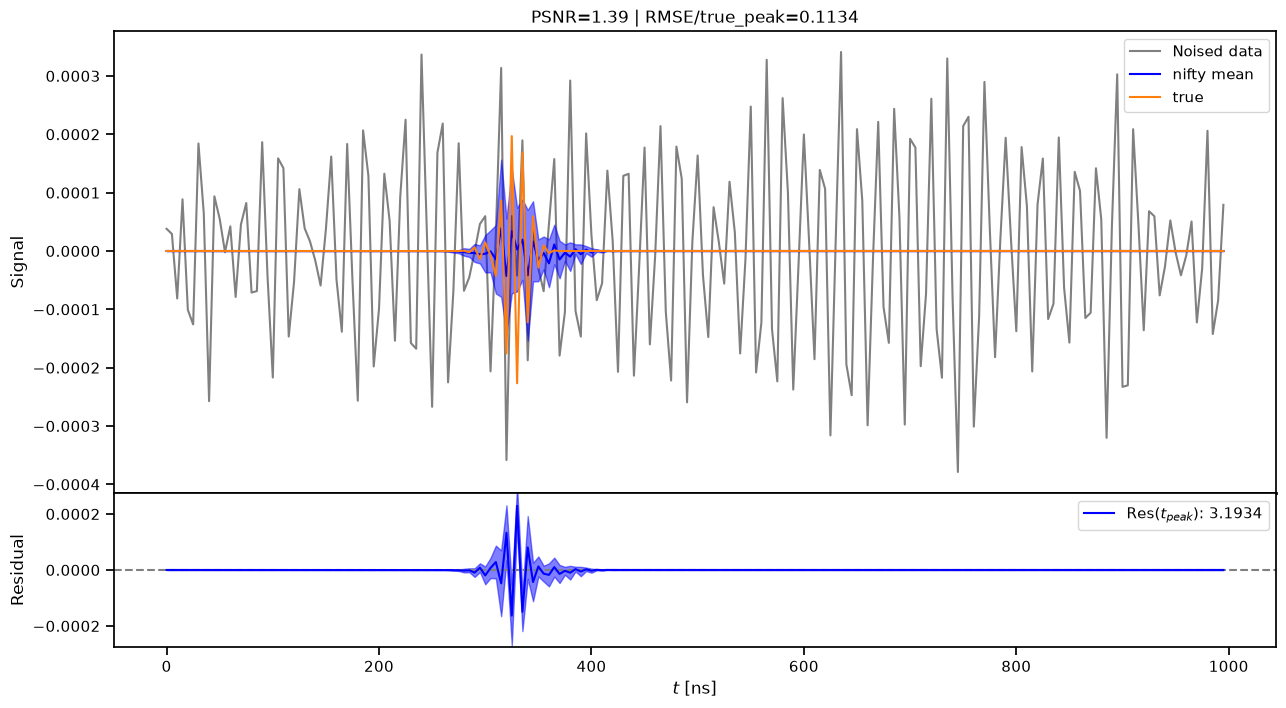

In [109]:
idx= 0
res = compare(means_diag[idx], stds_diag[idx], t200, d_true[idx], d[idx], norm_rmses_diag[idx])

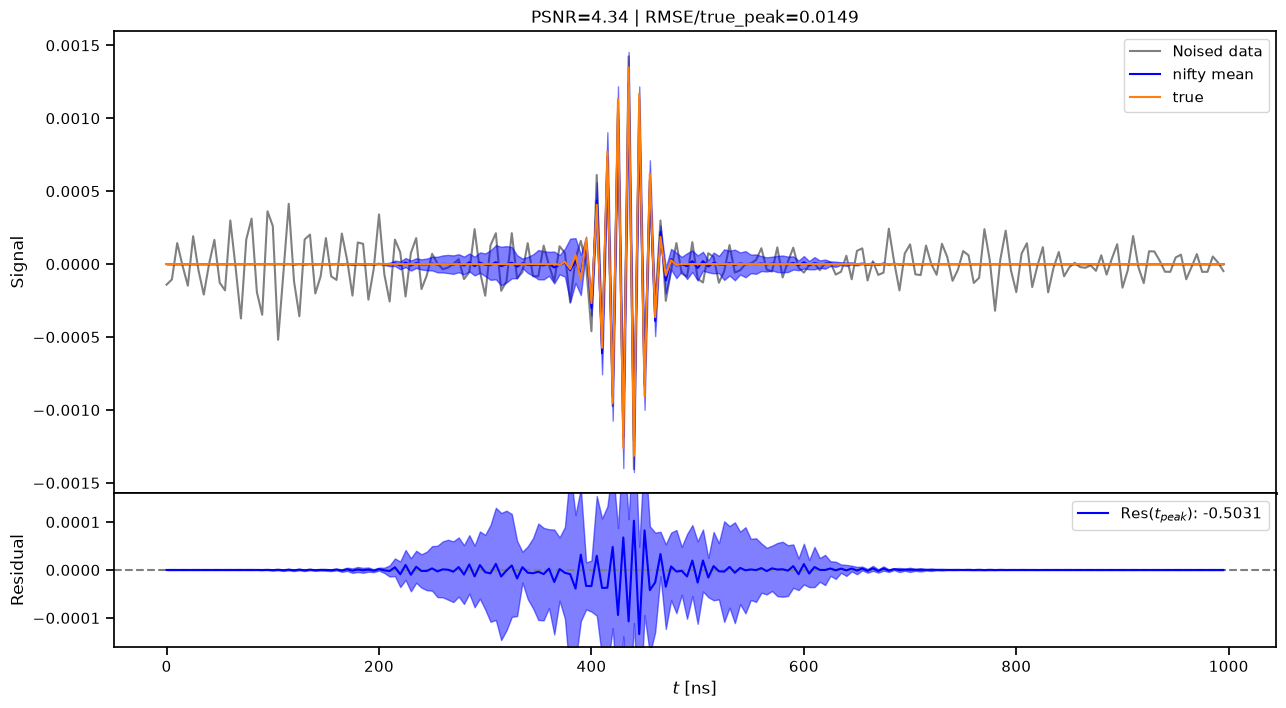

In [110]:
idx= 1
res = compare(means_diag[idx], stds_diag[idx], t200, d_true[idx], d[idx], norm_rmses_diag[idx])

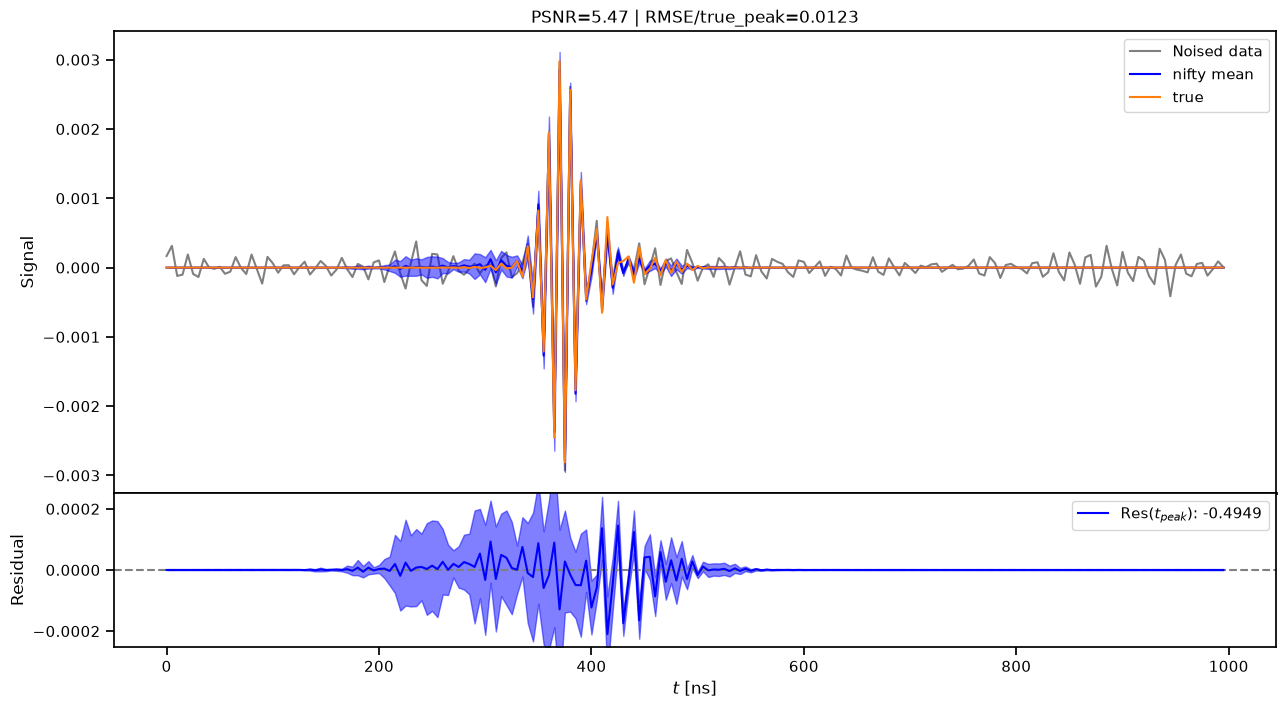

In [111]:
idx= 2
res = compare(means_diag[idx], stds_diag[idx], t200, d_true[idx], d[idx], norm_rmses_diag[idx])

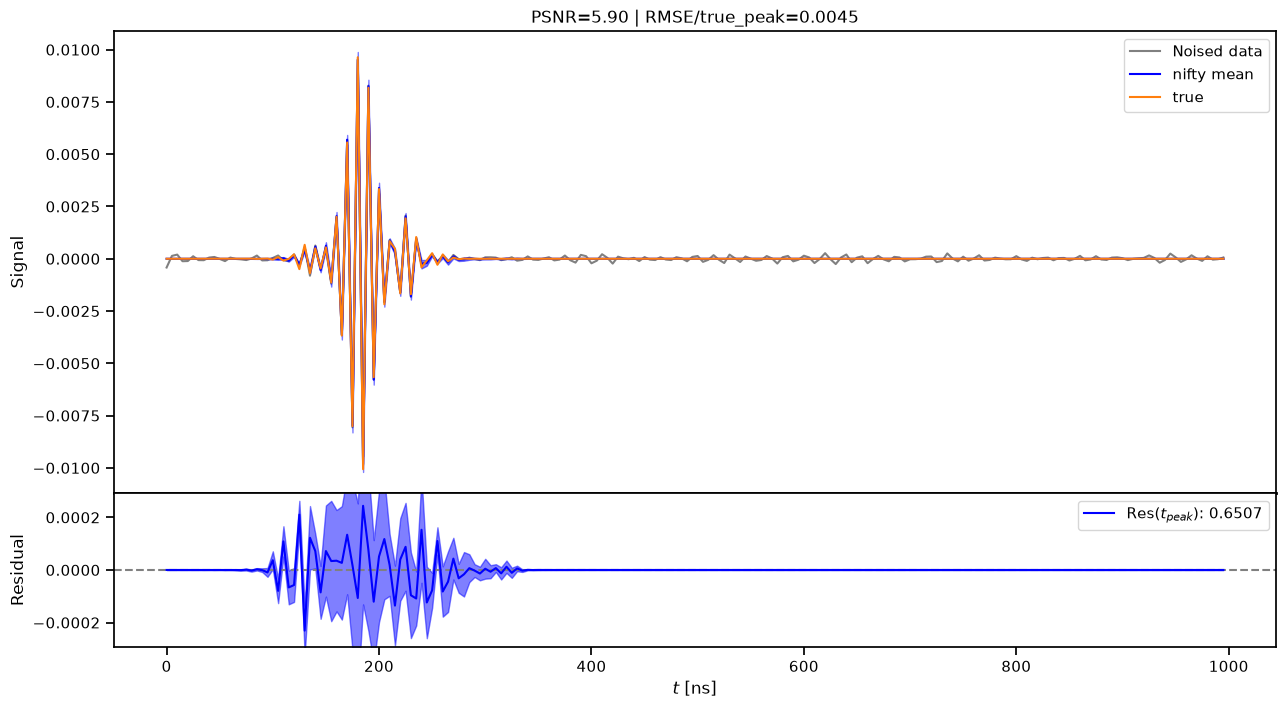

In [112]:
idx= 3
res = compare(means_diag[idx], stds_diag[idx], t200, d_true[idx], d[idx], norm_rmses_diag[idx])

In [113]:
np.save("results/mock1/means_diag.npy", means_diag)
np.save("results/mock1/stds_diag.npy", stds_diag)
np.save("results/mock1/rmses_diag.npy", rmses_diag)
np.save("results/mock1/norm_rmses_diag.npy", norm_rmses_diag)

In [114]:
def snr_uwr_peak(y_true, y_noise, y_mean, y_std):
    snr = np.max(np.abs(y_true), axis=1)/np.sqrt(np.mean(np.square(y_noise[:, -50:]), axis=1))
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.arange(len(abs_res)), np.argmax(np.abs(y_true), axis=1)]

    return snr, abs_res_peak

In [115]:
def snr_uwr(y_true, y_noise, y_mean, y_std):
    snr = np.max(np.abs(y_true), axis=1)/np.sqrt(np.mean(np.square(y_noise[:, -50:]), axis=1))
    diff = y_mean - y_true
    abs_res = diff/y_std

    return snr, np.mean(abs_res, axis=1), np.std(abs_res, axis=1)/np.sqrt(len(y_mean))

In [116]:
snr_diag, uwr_peak_diag = snr_uwr_peak(d_true, d, means_diag, stds_diag)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/1738862909.py:4: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


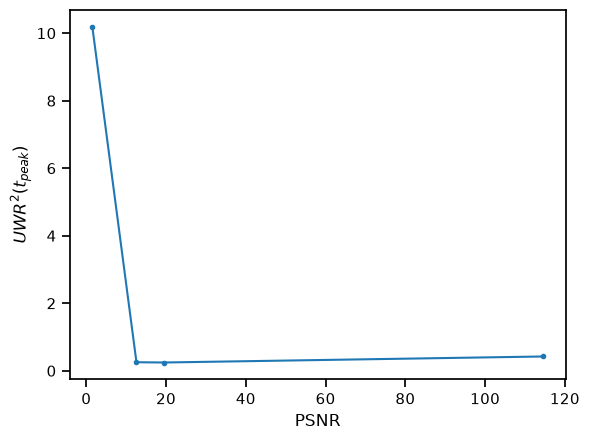

In [117]:
plt.plot(snr_diag, uwr_peak_diag**2, marker=".")
plt.xlabel("PSNR")
plt.ylabel(r"$UWR^2(t_{peak})$")
plt.show()

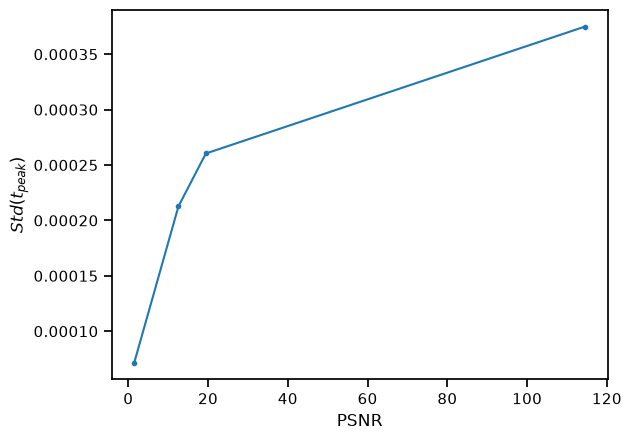

In [118]:
stds_peak_diag = stds_diag[np.arange(len(stds_diag)), np.argmax(np.abs(d_true), axis=1)]

plt.plot(snr_diag, stds_peak_diag, marker=".")
plt.xlabel("PSNR")
plt.ylabel(r"$Std(t_{peak})$")
plt.show()

In [119]:
def calc_RMSE_err(y_mean, y_true, y_std):
    # calculate statistical measurements
    diff = y_mean - y_true
    R = np.sqrt(np.mean(diff** 2, axis=1)) #Root mean square

    N = y_mean.shape[1]

    R_err = (1/N * R) * np.sqrt(np.sum(diff**2 * y_std**2, axis=1))
    return R, R_err

In [120]:
rmse_diag, rmse_err_diag = calc_RMSE_err(means_diag, d_true, stds_diag)

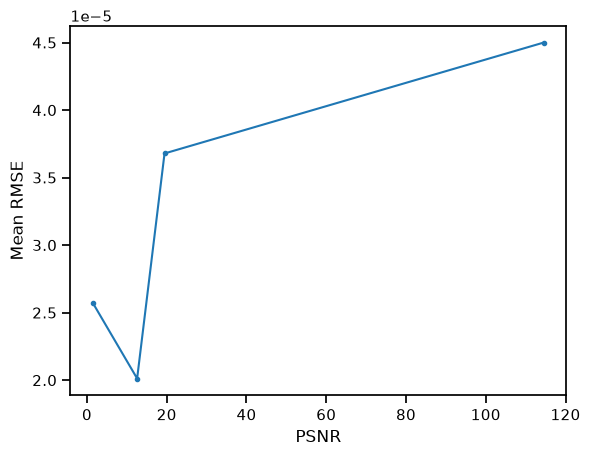

In [121]:
plt.errorbar(snr_diag, rmse_diag, rmse_err_diag, marker=".")
plt.xlabel("PSNR")
plt.ylabel("Mean RMSE")
plt.show()

## SKA-low
### Generate Mock signals

In [133]:
t200

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320,
       325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385,
       390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450,
       455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515,
       520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580,
       585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645,
       650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710,
       715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775,
       780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840,
       845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 90

In [139]:
dt_ska = 1.25e-9                          # [s]  (CF distances, filter frequencies)
N_ska = 800
t800 = np.arange(N_ska) * dt_ska * 1e9    # [ns] (window priors are in ns!)
np.save("data/time_800.npy", t800)   # ns, like time_200.npy (all_chan.py assumes ns)

In [140]:
Cov = np.load("../SKA_Cov/results/200K_1000samples_size800/Cov.npy")
noise_rms = np.sqrt(np.mean(np.diag(Cov)))

# 1) The empirical SKA covariance is singular (~30 zero eigenvalues: no noise power
#    near the 400 MHz Nyquist edge) -> cholesky gives NaN and inv() is meaningless.
#    Add a tiny white floor (-30 dB of the noise variance).
Cov = Cov + 1e-3 * noise_rms**2 * np.eye(len(Cov))

# 2) Use symmetric square roots: Std @ Std = Cov and Inv_Std @ Inv_Std = Inv_Cov.
#    (noise = cholesky(Cov) @ xi uses the *upper* factor U, whose noise covariance
#     U @ U.T differs from Cov by ~75 % here: 2.4x too much variance at the start of
#     the trace, ~0.15x in the last 50 bins where PSNR is measured.)
w_cov, V_cov = np.linalg.eigh(Cov)
Std = (V_cov * np.sqrt(w_cov)) @ V_cov.T
Inv_Std = (V_cov / np.sqrt(w_cov)) @ V_cov.T
Inv_Cov = (V_cov / w_cov) @ V_cov.T

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)
noise_cov = lambda x: jnp.matmul(Cov, x)
noise_std = lambda x: jnp.matmul(Std, x)

print(f"noise rms = {noise_rms:.3e} V,  cond(Cov) = {w_cov.max() / w_cov.min():.2e}")

noise rms = 1.266e-05 V,  cond(Cov) = 1.58e+04


In [141]:
from scipy.signal import butter, freqs_zpk


def butter_bandpass_response(freqs_hz, passband=(50e6, 350e6), order=10):
    # complex response of the analog Butterworth used in the SKA simulation
    # (NuRadioReco channelBandPassFilter, filter_type="butter", order=10)
    z, p, k = butter(order, [passband[0] / 1e9, passband[1] / 1e9], "bandpass", analog=True, output="zpk")
    H = np.zeros(len(freqs_hz), dtype=complex)
    pos = freqs_hz > 0
    H[pos] = freqs_zpk(z, p, k, worN=freqs_hz[pos] / 1e9)[1]
    return H


H_ska = jnp.asarray(butter_bandpass_response(np.fft.rfftfreq(N_ska, d=dt_ska)))


class SKASignalModel(jft.Model):
    # signal = BandPass[ CF * GaussianWindow ]
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, x_grid, H):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.window_std_prior = window_std_prior
        self.x_grid = x_grid
        self.H = H

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid - x0)**2 / (2 * sigma**2))

    def __call__(self, x):
        pulse = self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), self.window_std_prior(x))
        return jnp.fft.irfft(jnp.fft.rfft(pulse) * self.H, n=self.x_grid.shape[0])


# ---- SKA priors (shape) --------------------------------------------------
ska_shape_kwargs = {
    "loglogavgslope": (-1.1, 0.2),   # red CF spectrum -> ~f^-2.3 inside 50-350 MHz after windowing (sim: f^-2.1 / f^-2.6)
    "flexibility": (0.3, 0.15),      # mild spectral variety between draws
    "asperity": None,
}
ska_x0 = dict(mean=300., std=20.)    # [ns] pulse position (keeps ringing tail + last 50 bins noise-only)
ska_sigma = dict(mean=3.3, std=0.5)  # [ns] window width (LogNormal: always > 0)


def make_ska_model(flu_mean, flu_std, x0_std=ska_x0["std"]):
    cf_kwargs = {
        "offset_mean": 0.,
        "offset_std": (1e-3 * flu_mean, 1e-4 * flu_mean),  # ~no DC offset (band-pass removes it anyway)
        "fluctuations": (flu_mean, flu_std),               # <- amplitude, i.e. PSNR
        "prefix": "",
        **ska_shape_kwargs,
    }
    cf_model, ps = fieldmaker(shape=N_ska, distances=dt_ska, **cf_kwargs)
    x0 = jft.NormalPrior(mean=ska_x0["mean"], std=x0_std, name="mean_pos_window", shape=(1,))
    sigma = jft.LogNormalPrior(mean=ska_sigma["mean"], std=ska_sigma["std"], name="std_window", shape=(1,))
    return SKASignalModel(cf_model, x0, sigma, t800, H_ska), ps

In [142]:
# ---- amplitude prior from a target PSNR distribution ---------------------------
psnr_median = 10.    # median PSNR of prior draws
psnr_logstd = 0.65   # ln-spread from `fluctuations`; the shape priors add ~0.7 -> 90% of draws in ~[2, 50]

# calibrate peak(signal) per unit `fluctuations` for these shape priors (expected ~0.18)
unit_model, _ = make_ska_model(1.0, 1e-6)
draw_unit = jax.jit(lambda k: unit_model(jft.random_like(k, unit_model.domain)))
key, sk = random.split(key)
g_med = np.median([np.max(np.abs(draw_unit(k))) for k in random.split(sk, 300)])

flu_med = psnr_median * noise_rms / g_med
flu_mean = flu_med * np.exp(psnr_logstd**2 / 2)             # LogNormal (mean, std) with that median / ln-std
flu_std = flu_mean * np.sqrt(np.exp(psnr_logstd**2) - 1)
print(f"g_med = {g_med:.3f}  ->  fluctuations = ({flu_mean:.3e}, {flu_std:.3e})")

my_model, ps = make_ska_model(flu_mean, flu_std)

g_med = 0.187  ->  fluctuations = (8.361e-04, 6.063e-04)


PSNR of prior draws (5/16/50/84/95 %): [ 1.61  3.17  9.78 24.93 41.74]
simulated SKA pulse (ch0): PSNR = 9.8


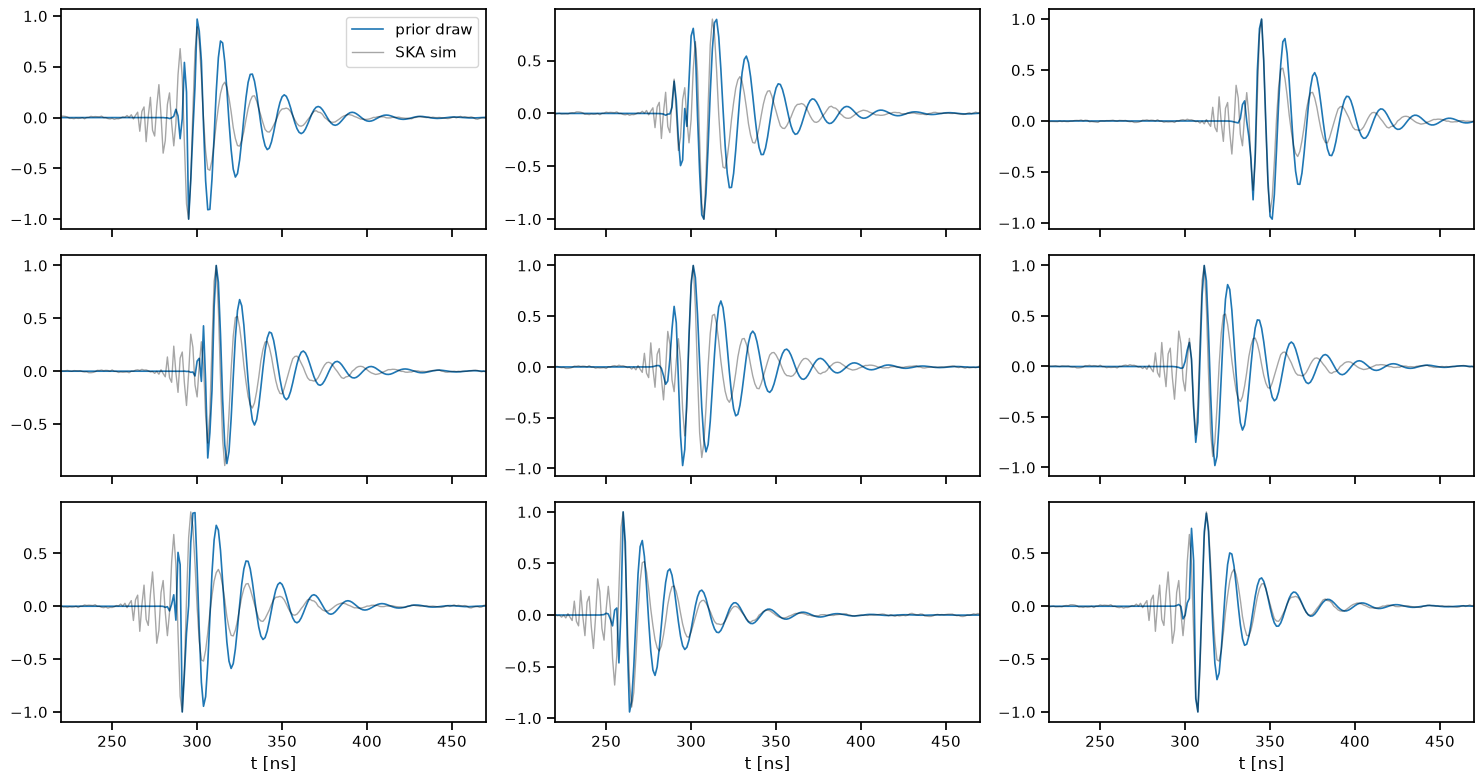

In [143]:
# Sanity check: prior draws vs the simulated SKA pulse + PSNR spread of the prior
tr_ska = np.load("../SKA_Cov/results/200K_1000samples_size800/traces.npy")
ref = tr_ska[0::2].mean(axis=0)   # every realisation has the same CoREAS pulse -> averaging removes the noise
t_ref = np.arange(len(ref)) * 1.25

draw = jax.jit(lambda k: my_model(jft.random_like(k, my_model.domain)))
key, sk = random.split(key)
sigs = np.array([draw(k) for k in random.split(sk, 300)])
psnr_prior = np.max(np.abs(sigs), axis=1) / noise_rms
print("PSNR of prior draws (5/16/50/84/95 %):", np.percentile(psnr_prior, [5, 16, 50, 84, 95]).round(2))
print(f"simulated SKA pulse (ch0): PSNR = {np.max(np.abs(ref)) / noise_rms:.1f}")

sns.set_context("notebook")
fig, axes = plt.subplots(3, 3, figsize=(15, 8), sharex=True)
j = np.argmax(np.abs(ref))
for ax, s in zip(axes.flat, sigs):
    i = np.argmax(np.abs(s))
    ax.plot(t800, s / np.abs(s).max(), lw=1.2, label="prior draw")
    ax.plot(t_ref - t_ref[j] + t800[i], ref / np.abs(ref).max() * np.sign(s[i]), c="k", alpha=0.35, lw=1, label="SKA sim")
    ax.set_xlim(220, 470)
axes[0, 0].legend()
for ax in axes[-1]:
    ax.set_xlabel("t [ns]")
plt.tight_layout()
plt.show()

In [144]:
signal_options = []
data_options = []

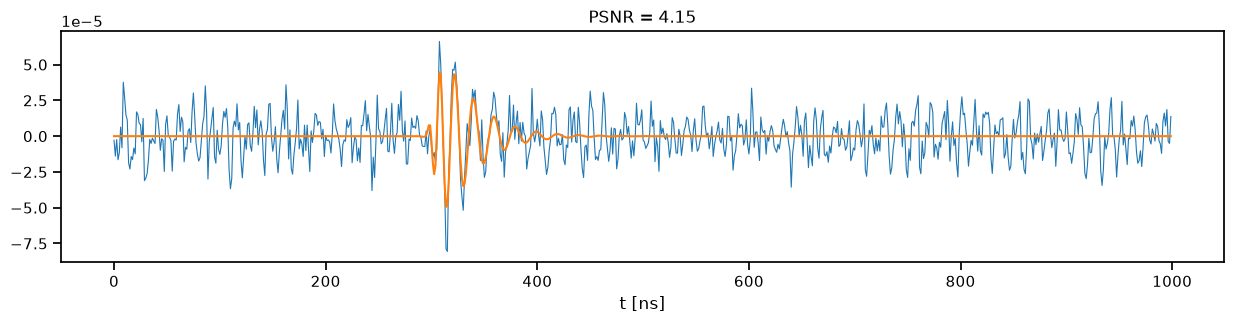

In [155]:
key, k_sig, k_noise = random.split(key, 3)
mock_signal = my_model(jft.random_like(k_sig, my_model.domain))

target_psnr = None   # e.g. 5. -> keep the drawn shape but rescale it to exactly this PSNR
if target_psnr is not None:
    mock_signal = mock_signal * target_psnr * noise_rms / jnp.max(jnp.abs(mock_signal))

noise = noise_std(jft.random_like(k_noise, my_model.target))
mock_data = mock_signal + noise

psnr = np.max(np.abs(mock_signal)) / np.sqrt(np.mean(np.square(mock_data[-50:])))
sns.set_context("notebook")
plt.figure(figsize=(15, 3))
plt.plot(t800, mock_data, c="tab:blue", lw=0.8)
plt.plot(t800, mock_signal, c="tab:orange")
plt.xlabel("t [ns]")
plt.title(f"PSNR = {psnr:.2f}")
plt.show()

In [156]:
signal_options.append(mock_signal)
data_options.append(mock_data)

In [157]:
len(signal_options)

4

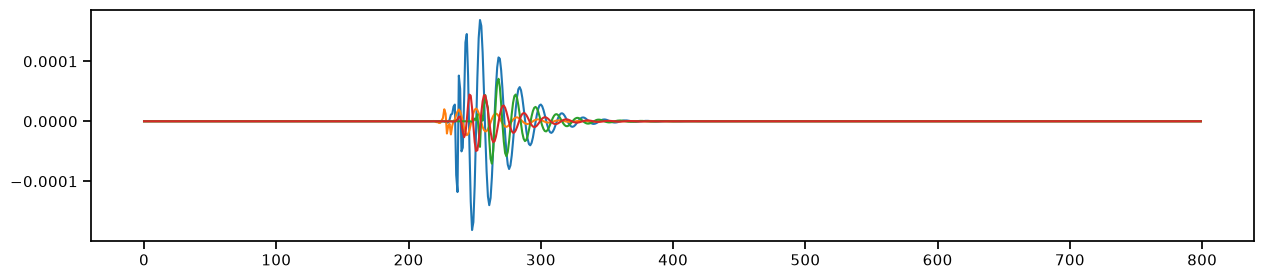

In [158]:
plt.figure(figsize=(15, 3))
for signal in signal_options:
    plt.plot(signal)
plt.show()

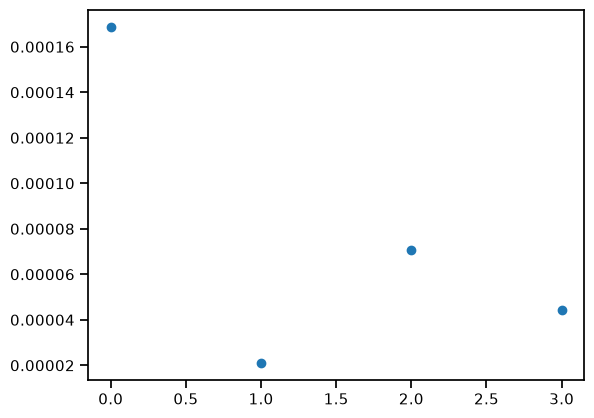

In [159]:
plt.scatter(np.arange(len(signal_options)), np.max(np.array(signal_options), axis=1))
plt.show()

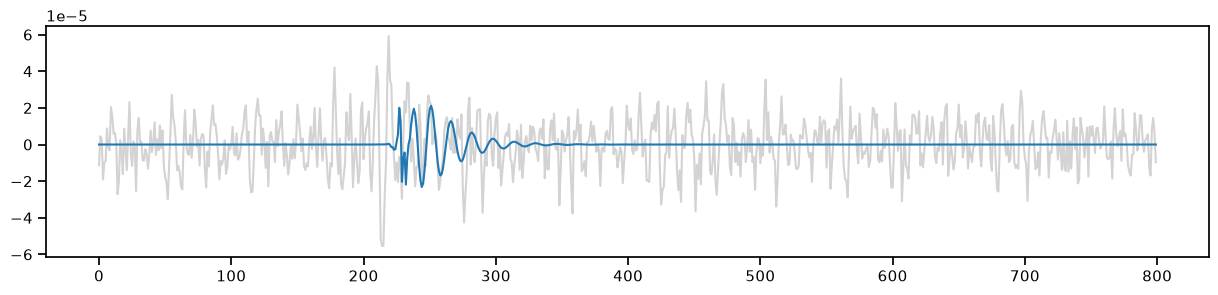

In [160]:
idx = 1
plt.figure(figsize=(15,3))
plt.plot(data_options[idx], c="lightgray")
plt.plot(signal_options[idx])
plt.show()

In [161]:
np.save("data/ska_mock_signal1.npy", np.array(signal_options))
np.save("data/ska_mock_data1.npy", np.array(data_options))

### With SKA Cov


In [162]:
ska_d = np.load("data/ska_mock_data1.npy")
ska_d_true = np.load("data/ska_mock_signal1.npy")

In [164]:
# likelihood
tot = len(ska_d)

n=0
sus = []
ska_means = []
ska_stds = []
ska_rmses = []
ska_norm_rmses = []
now = time.time()

for i in range(tot):

    clear_output(wait=True)
    now = show_progress(now, i, tot)

    # ---- SKA priors (shape) --------------------------------------------------
    ska_shape_kwargs = {
        "loglogavgslope": (-1.1, 0.2),   # red CF spectrum -> ~f^-2.3 inside 50-350 MHz after windowing (sim: f^-2.1 / f^-2.6)
        "flexibility": (0.3, 0.15),      # mild spectral variety between draws
        "asperity": None,
    }
    ska_x0 = dict(mean=300., std=20.)    # [ns] pulse position (keeps ringing tail + last 50 bins noise-only)
    ska_sigma = dict(mean=3.3, std=0.5)  # [ns] window width (LogNormal: always > 0)


    def make_ska_model(flu_mean, flu_std, x0_std=ska_x0["std"]):
        cf_kwargs = {
            "offset_mean": 0.,
            "offset_std": (1e-3 * flu_mean, 1e-4 * flu_mean),  # ~no DC offset (band-pass removes it anyway)
            "fluctuations": (flu_mean, flu_std),               # <- amplitude, i.e. PSNR
            "prefix": "",
            **ska_shape_kwargs,
        }
        cf_model, ps = fieldmaker(shape=N_ska, distances=dt_ska, **cf_kwargs)
        x0 = jft.NormalPrior(mean=ska_x0["mean"], std=x0_std, name="mean_pos_window", shape=(1,))
        sigma = jft.LogNormalPrior(mean=ska_sigma["mean"], std=ska_sigma["std"], name="std_window", shape=(1,))
        return SKASignalModel(cf_model, x0, sigma, t800, H_ska), ps

    # ---- amplitude prior from a target PSNR distribution ---------------------------
    psnr_median = 10.    # median PSNR of prior draws
    psnr_logstd = 0.65   # ln-spread from `fluctuations`; the shape priors add ~0.7 -> 90% of draws in ~[2, 50]

    # calibrate peak(signal) per unit `fluctuations` for these shape priors (expected ~0.18)
    unit_model, _ = make_ska_model(1.0, 1e-6)
    draw_unit = jax.jit(lambda k: unit_model(jft.random_like(k, unit_model.domain)))
    key, sk = random.split(key)
    g_med = np.median([np.max(np.abs(draw_unit(k))) for k in random.split(sk, 300)])

    flu_med = psnr_median * noise_rms / g_med
    flu_mean = flu_med * np.exp(psnr_logstd**2 / 2)             # LogNormal (mean, std) with that median / ln-std
    flu_std = flu_mean * np.sqrt(np.exp(psnr_logstd**2) - 1)
    print(f"g_med = {g_med:.3f}  ->  fluctuations = ({flu_mean:.3e}, {flu_std:.3e})")

    my_model, ps = make_ska_model(flu_mean, flu_std)

    lh = jft.Gaussian(data=ska_d[i], noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

    key, subkey = random.split(key, 2)
    init_pos = jft.Vector(lh.init(subkey))
    n_vi_iterations = 6
    n_samples = 4

    key, sampling_key = random.split(key, 2)

    draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
    )

    kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

    sample_mode = "linear_resample"

    optimize_kl_args = dict(
        likelihood=lh,
        position_or_samples=init_pos,
        n_total_iterations=n_vi_iterations,
        n_samples=n_samples,
        key=sampling_key,
        draw_linear_kwargs=draw_linear_kwargs,
        kl_kwargs=kl_kwargs,
        sample_mode=sample_mode,
        )

    s, state = jft.optimize_kl(**optimize_kl_args)

    y_samples = tuple(my_model(s) for s in s)
    y_mean, y_std = jft.mean_and_std(y_samples)
    ska_means.append(y_mean)
    ska_stds.append(y_std)

    ska_rmse=calc_RMSE(y_mean, ska_d_true[i])
    ska_norm_rmse = ska_rmse/np.max(np.abs(ska_d_true[i])) 
    ska_rmses.append(ska_rmse)
    ska_norm_rmses.append(ska_norm_rmse)

    if ska_norm_rmse > 0.1:
        # sus.append(f"IDX {i}: RMSE/max_amp={norm_rmse:.4f}")
        n += 1

clear_output(wait=True)
print("=== All Channels complete ===")
print(f"Total Suspicious Indices: {n}/{tot}\n")
# if sus:
#     print("Full Log of Anomalies:")
#     for log_entry in sus:
#         print(f"  * {log_entry}")

ska_means = np.array(ska_means)
ska_stds = np.array(ska_stds)
ska_rmses = np.array(ska_rmses)
ska_norm_rmses = np.array(ska_norm_rmses)

=== All Channels complete ===
Total Suspicious Indices: 1/4



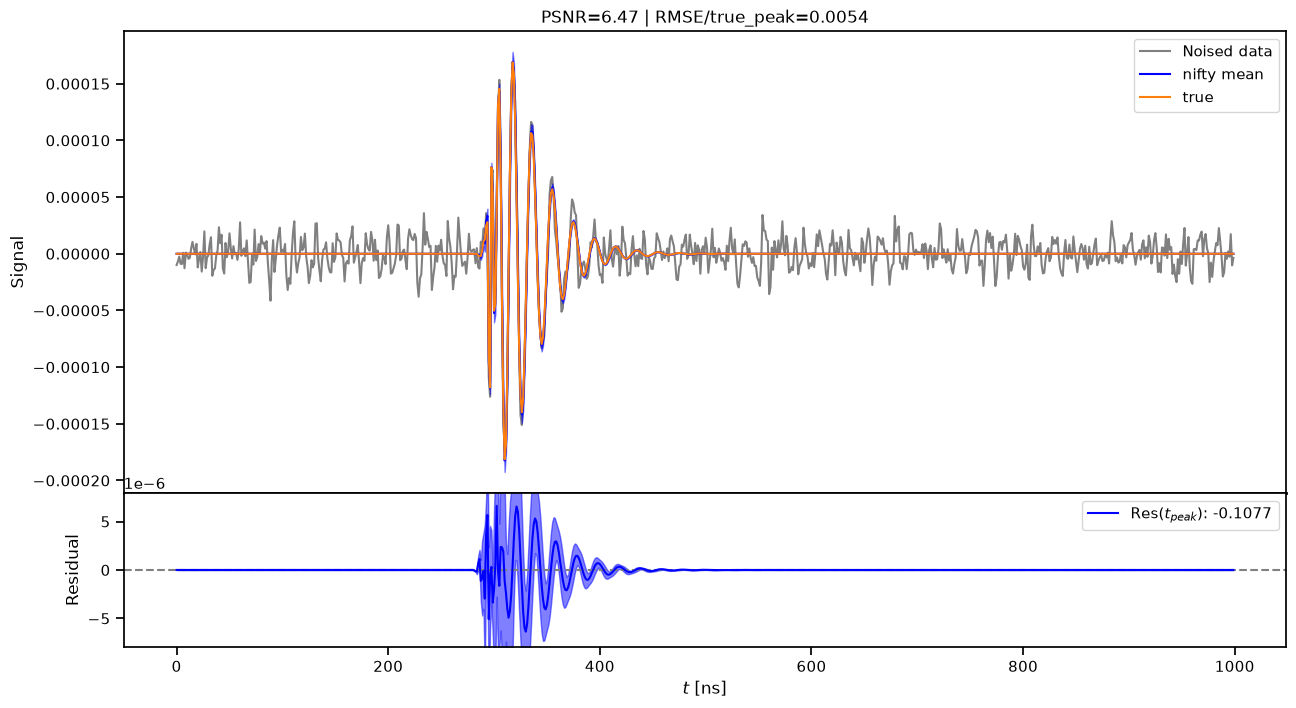

In [169]:
idx= 0
res = compare(ska_means[idx], ska_stds[idx], t800, ska_d_true[idx], ska_d[idx], ska_norm_rmses[idx])

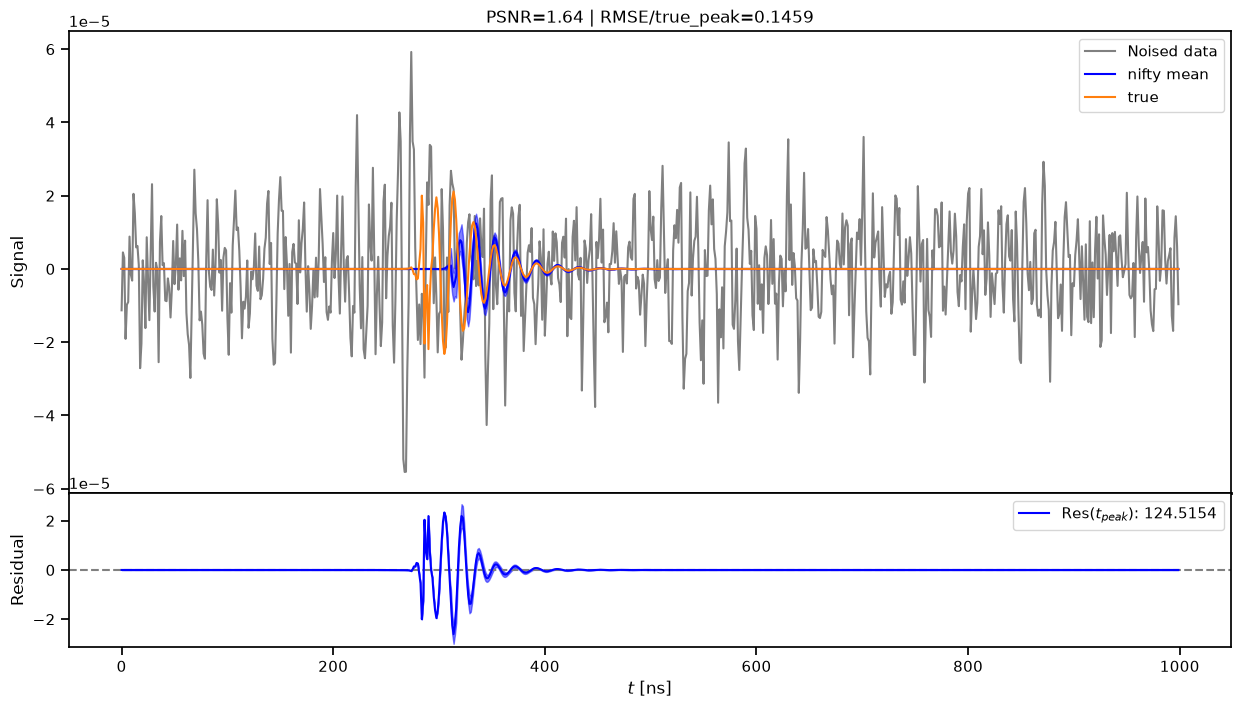

In [170]:
idx= 1
res = compare(ska_means[idx], ska_stds[idx], t800, ska_d_true[idx], ska_d[idx], ska_norm_rmses[idx])

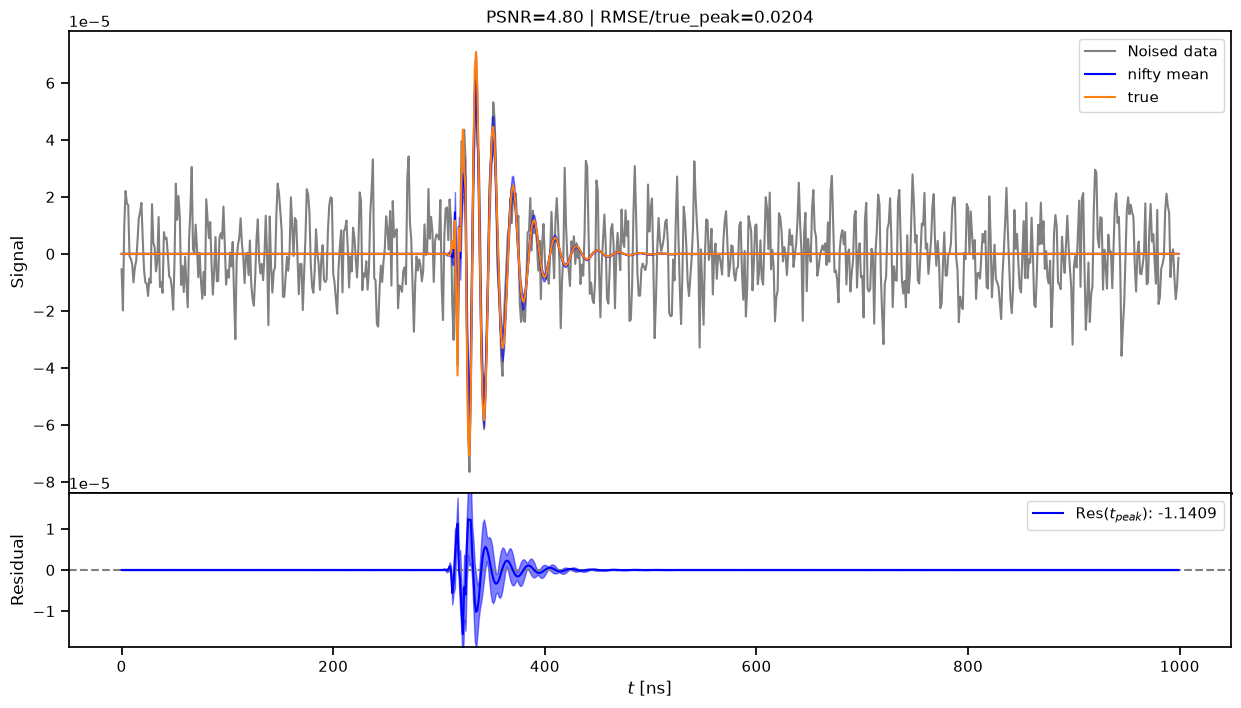

In [171]:
idx= 2
res = compare(ska_means[idx], ska_stds[idx], t800, ska_d_true[idx], ska_d[idx], ska_norm_rmses[idx])

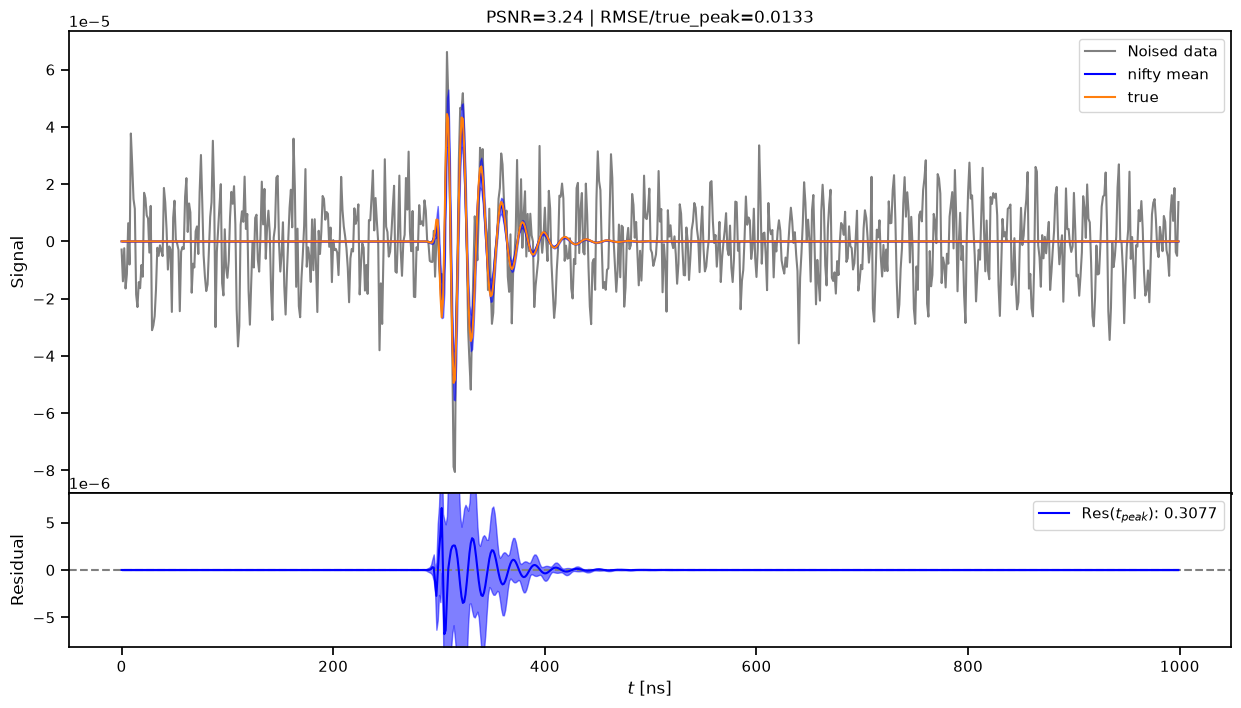

In [172]:
idx= 3
res = compare(ska_means[idx], ska_stds[idx], t800, ska_d_true[idx], ska_d[idx], ska_norm_rmses[idx])

In [173]:
np.save("results/mock1/ska_means.npy", ska_means)
np.save("results/mock1/ska_stds.npy", ska_stds)
np.save("results/mock1/ska_rmses.npy", ska_rmses)
np.save("results/mock1/ska_norm_rmses.npy", ska_norm_rmses)

In [175]:
ska_snr, ska_uwr_peak = snr_uwr_peak(ska_d_true, ska_d, ska_means, ska_stds)

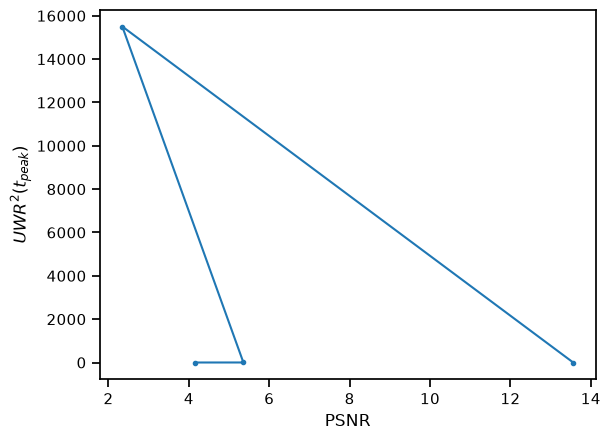

In [176]:
plt.plot(ska_snr, ska_uwr_peak**2, marker=".")
plt.xlabel("PSNR")
plt.ylabel(r"$UWR^2(t_{peak})$")
plt.show()

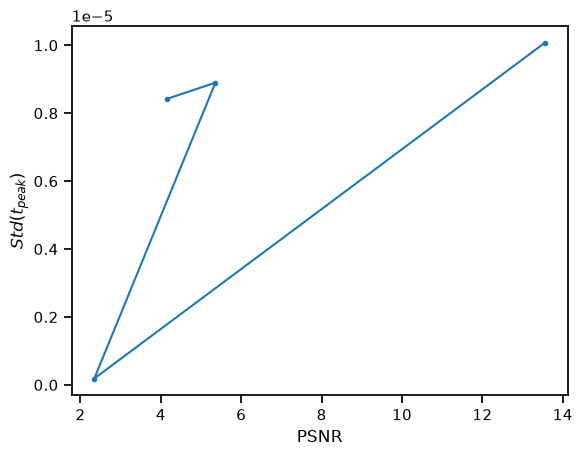

In [177]:
ska_stds_peak = ska_stds[np.arange(len(ska_stds)), np.argmax(np.abs(ska_d_true), axis=1)]

plt.plot(ska_snr, ska_stds_peak, marker=".")
plt.xlabel("PSNR")
plt.ylabel(r"$Std(t_{peak})$")
plt.show()

In [178]:
ska_rmse, ska_rmse_err = calc_RMSE_err(ska_means, ska_d_true, ska_stds)

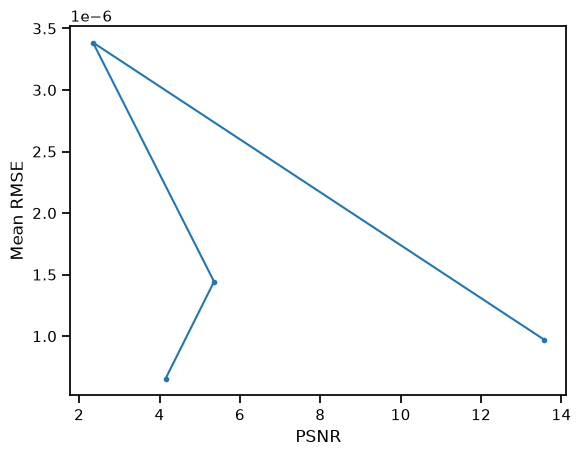

In [179]:
plt.errorbar(ska_snr, ska_rmse, ska_rmse_err, marker=".")
plt.xlabel("PSNR")
plt.ylabel("Mean RMSE")
plt.show()

# Slide figures

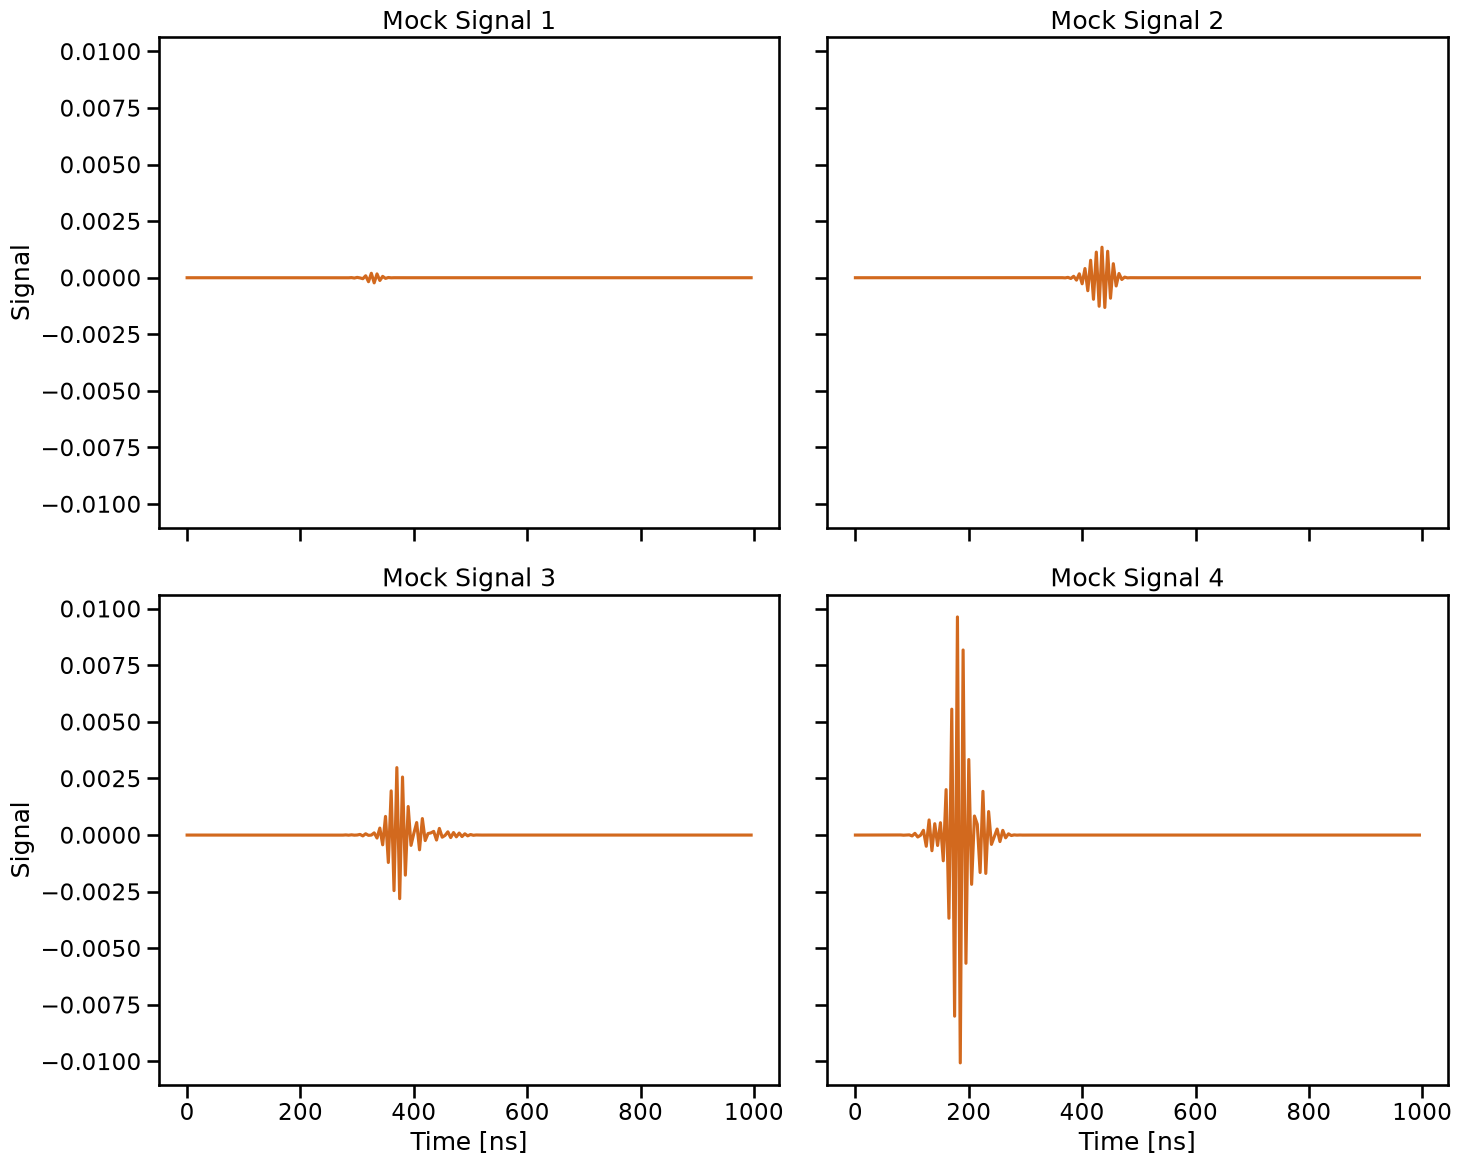

In [86]:
# Display all of d_true in a single figure with four plots, each showing a different index of d_true in 2x2 grid by defining subplots at the beginning
sns.set_context("talk")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True)

for i in range(4):
    axes[i//2, i%2].plot(t200, d_true[i], label="true", c="chocolate")
    axes[i//2, i%2].set_title(f"Mock Signal {i+1}")
    # axes[i//2, i%2].legend()

axes[1, 0].set_xlabel("Time [ns]")
axes[1, 1].set_xlabel("Time [ns]")
axes[0, 0].set_ylabel("Signal")
axes[1, 0].set_ylabel("Signal")

plt.tight_layout()
plt.show()

#save the figure
fig.savefig("../talk_figures/mock_signals_LOFAR.png", dpi=300)
plt.close(fig)

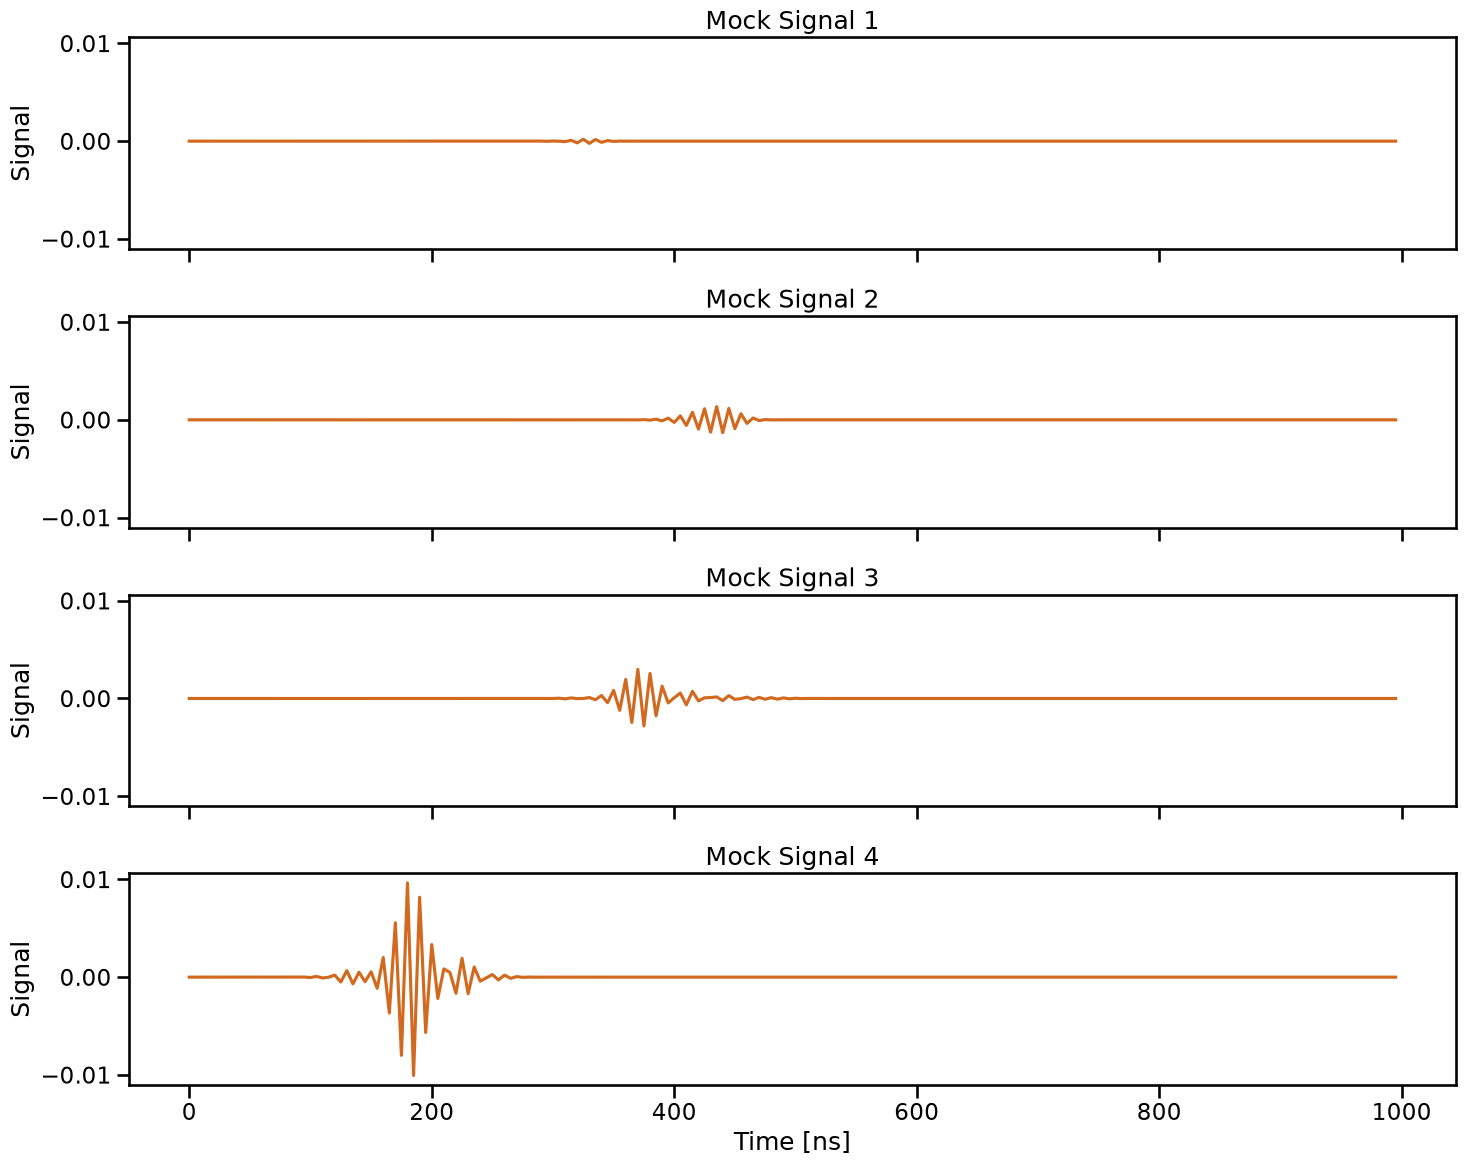

In [ ]:
# Display all of d_true in a single figure with four plots, each showing a different index of d_true in 2x2 grid by defining subplots at the beginning
sns.set_context("talk")

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True, sharey=True)

for i in range(4):
    axes[i].plot(t200, d_true[i], label="true", c="chocolate")
    axes[i].set_title(f"Mock Signal {i+1}")
    axes[i].set_ylabel("Signal")
    # axes[i].legend()

axes[3].set_xlabel("Time [ns]")

plt.tight_layout()
plt.show()

#save the figure
# fig.savefig("../talk_figures/mock_signals_LOFAR.png", dpi=300)
plt.close(fig)

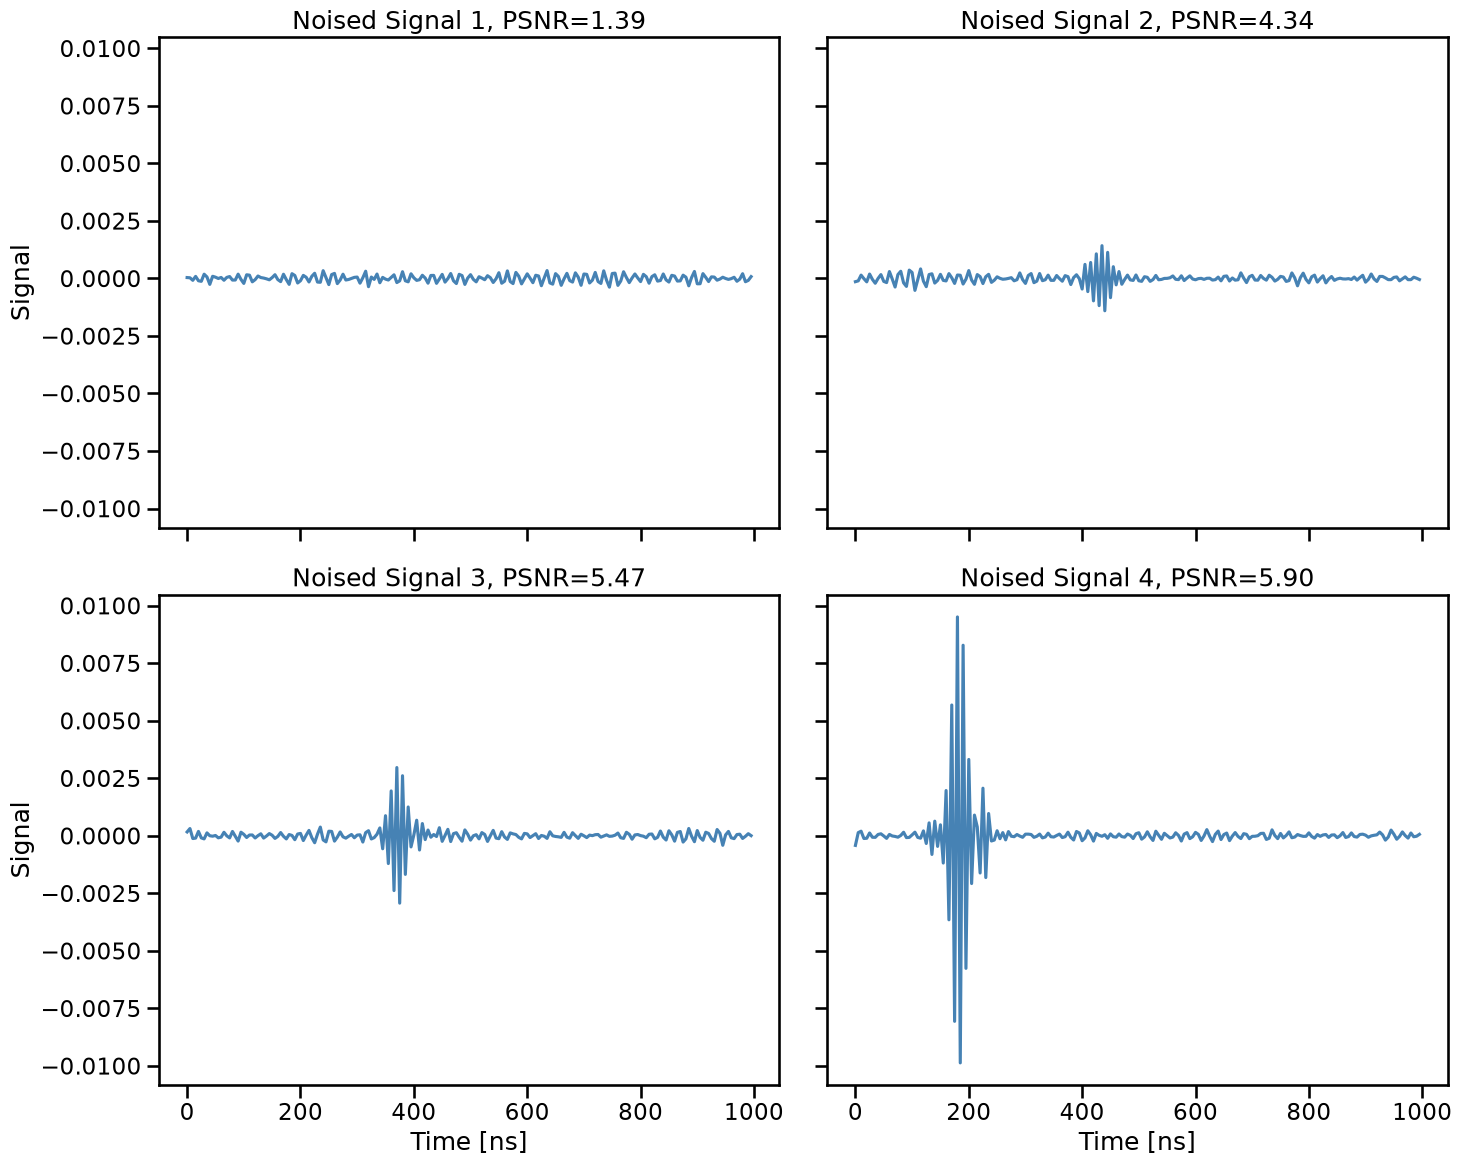

In [87]:
sns.set_context("talk")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True)

for i in range(4):
    axes[i//2, i%2].plot(t200, d[i], label="true", c="steelblue")
    snr = np.max(np.abs(d_true[i]))/np.sqrt(np.mean(np.square(d[i][:-50]-np.mean(d[i][:-50]))))
    axes[i//2, i%2].set_title(f"Noised Signal {i+1}, PSNR={snr:.2f}")
    # axes[i//2, i%2].legend()

axes[1, 0].set_xlabel("Time [ns]")
axes[1, 1].set_xlabel("Time [ns]")
axes[0, 0].set_ylabel("Signal")
axes[1, 0].set_ylabel("Signal")

plt.tight_layout()
plt.show()

#save the figure
fig.savefig("../talk_figures/noised_signals_LOFAR.png", dpi=300)
plt.close(fig)

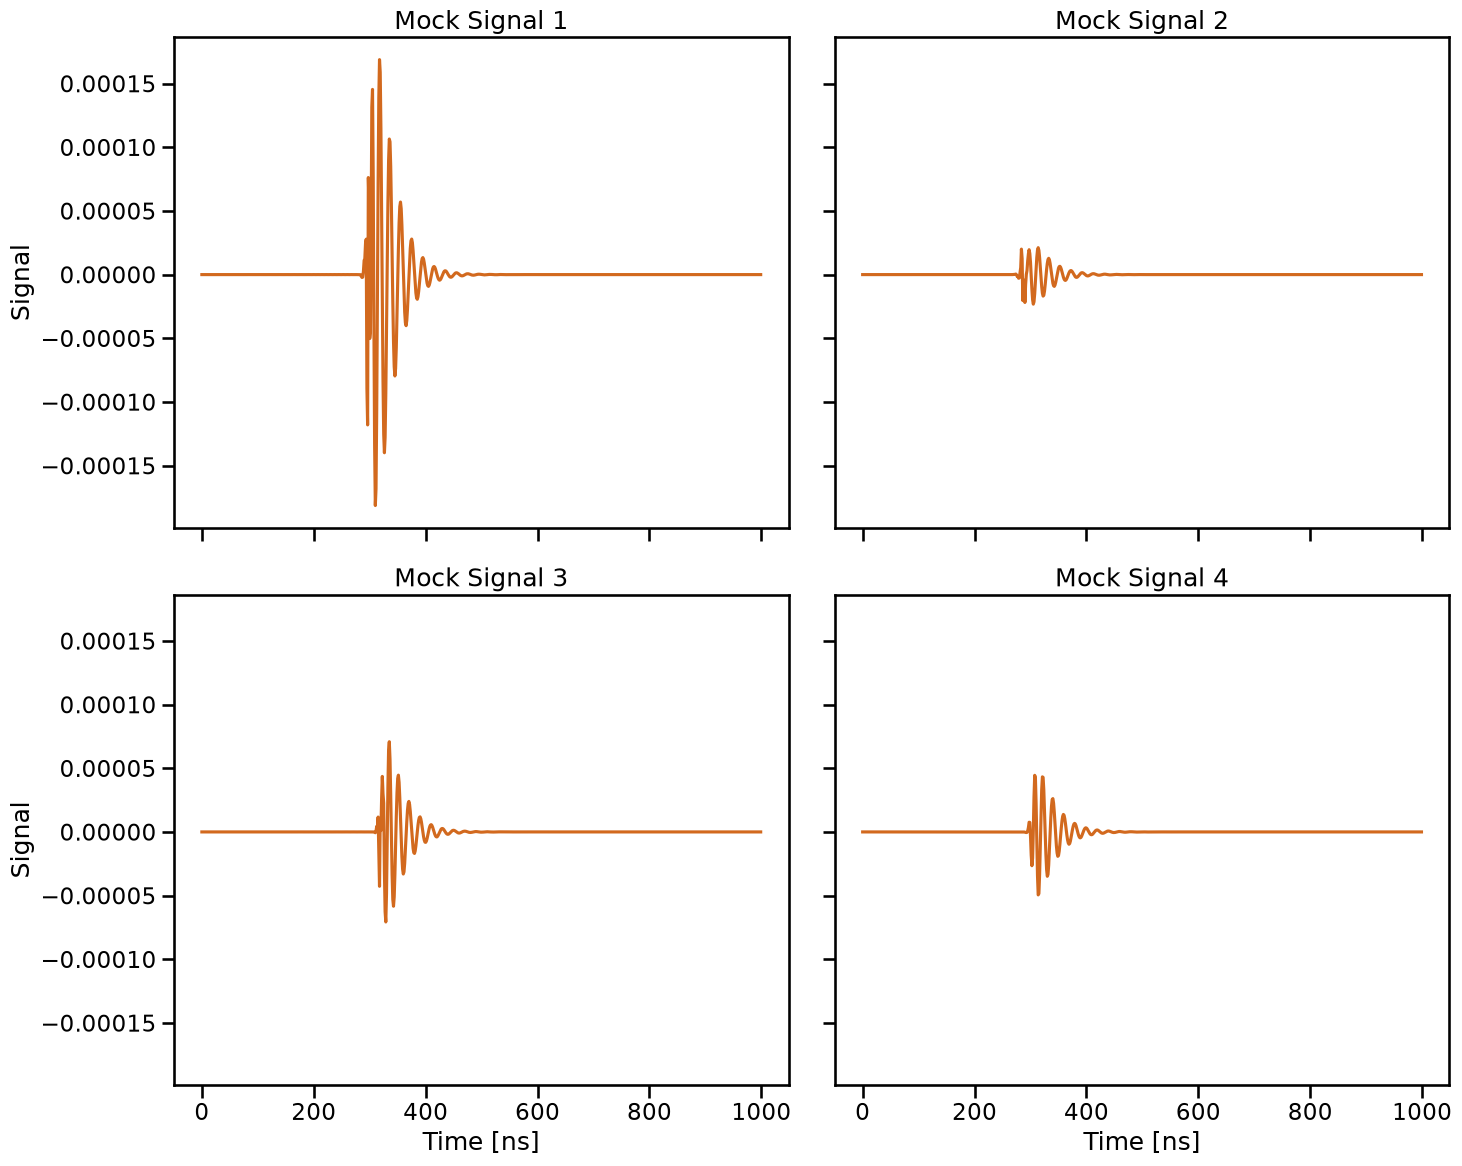

In [181]:
# Display all of d_true in a single figure with four plots, each showing a different index of d_true in 2x2 grid by defining subplots at the beginning
sns.set_context("talk")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True)

for i in range(4):
    axes[i//2, i%2].plot(t800, ska_d_true[i], label="true", c="chocolate")
    axes[i//2, i%2].set_title(f"Mock Signal {i+1}")
    # axes[i//2, i%2].legend()

axes[1, 0].set_xlabel("Time [ns]")
axes[1, 1].set_xlabel("Time [ns]")
axes[0, 0].set_ylabel("Signal")
axes[1, 0].set_ylabel("Signal")

plt.tight_layout()
plt.show()

#save the figure
fig.savefig("../talk_figures/mock_signals_SKA.png", dpi=300)
plt.close(fig)

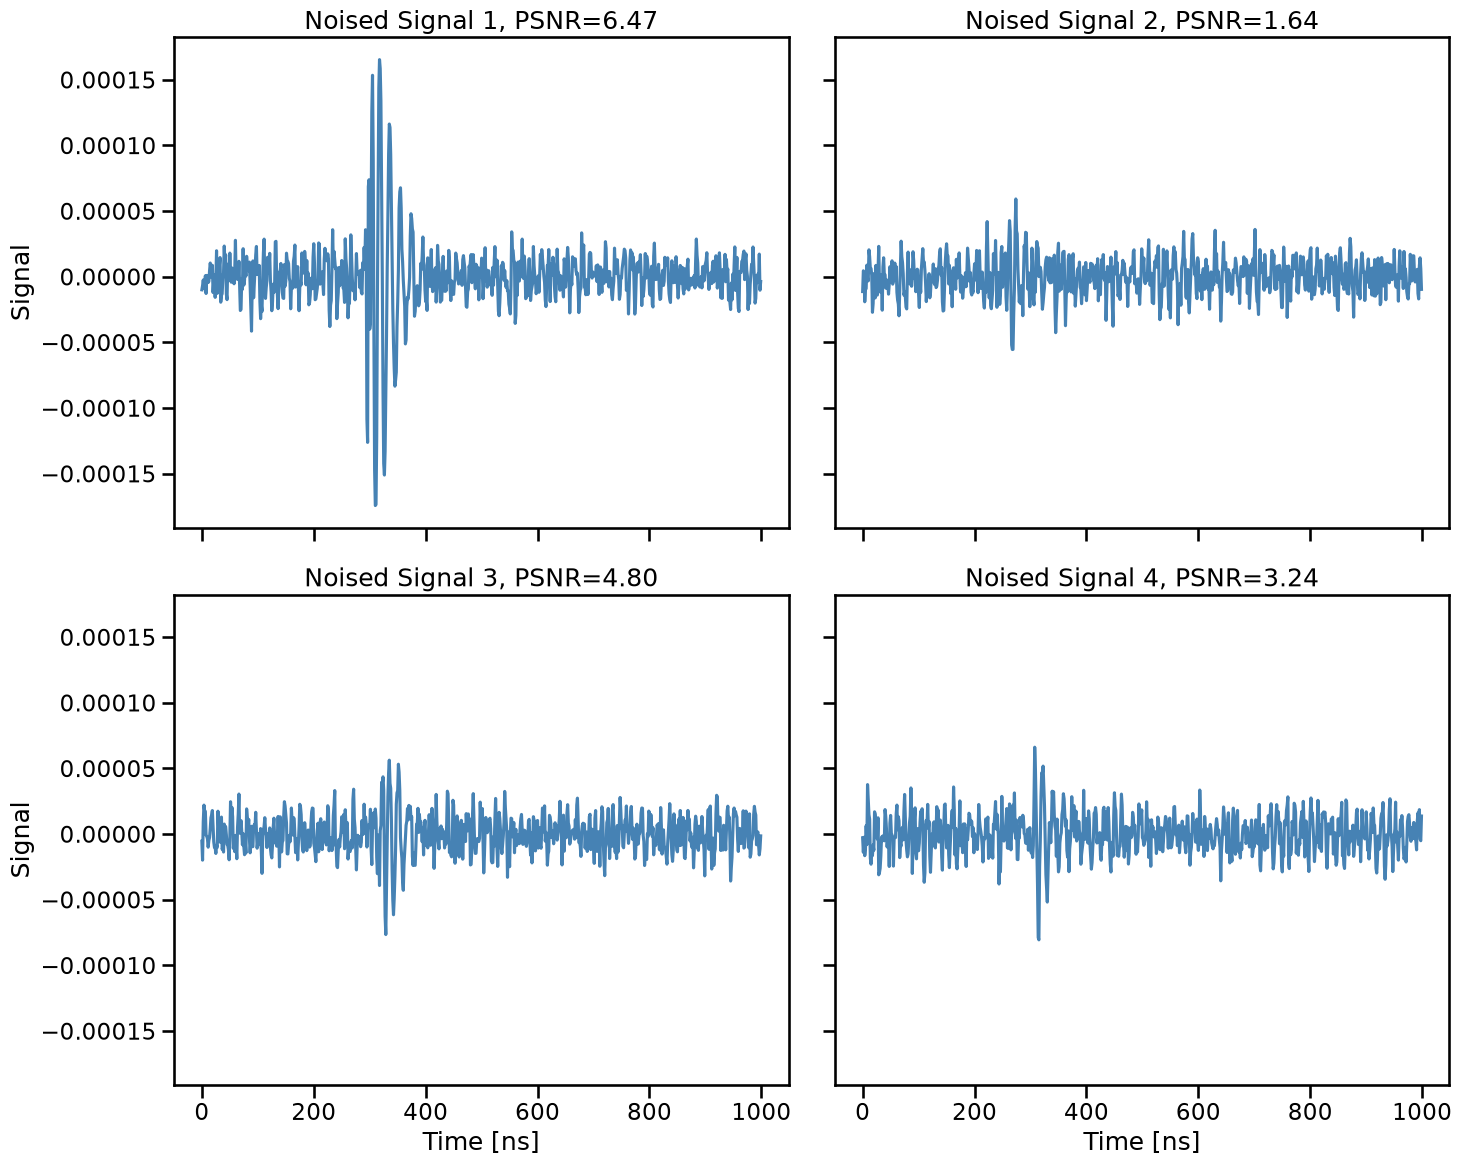

In [182]:
sns.set_context("talk")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True)

for i in range(4):
    axes[i//2, i%2].plot(t800, ska_d[i], label="true", c="steelblue")
    snr = np.max(np.abs(ska_d_true[i]))/np.sqrt(np.mean(np.square(ska_d[i][:-50]-np.mean(ska_d[i][:-50]))))
    axes[i//2, i%2].set_title(f"Noised Signal {i+1}, PSNR={snr:.2f}")
    # axes[i//2, i%2].legend()

axes[1, 0].set_xlabel("Time [ns]")
axes[1, 1].set_xlabel("Time [ns]")
axes[0, 0].set_ylabel("Signal")
axes[1, 0].set_ylabel("Signal")

plt.tight_layout()
plt.show()

#save the figure
fig.savefig("../talk_figures/noised_signals_SKA.png", dpi=300)
plt.close(fig)

In [ ]:
def compare(y_mean, y_std, x, y_true, y_noise, norm_rmse, compare="true"):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Res($t_{{peak}}$): {abs_res_peak:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")
    plt.show()

    return y_mean, y_std, diff, abs_res

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/3857859176.py:16: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


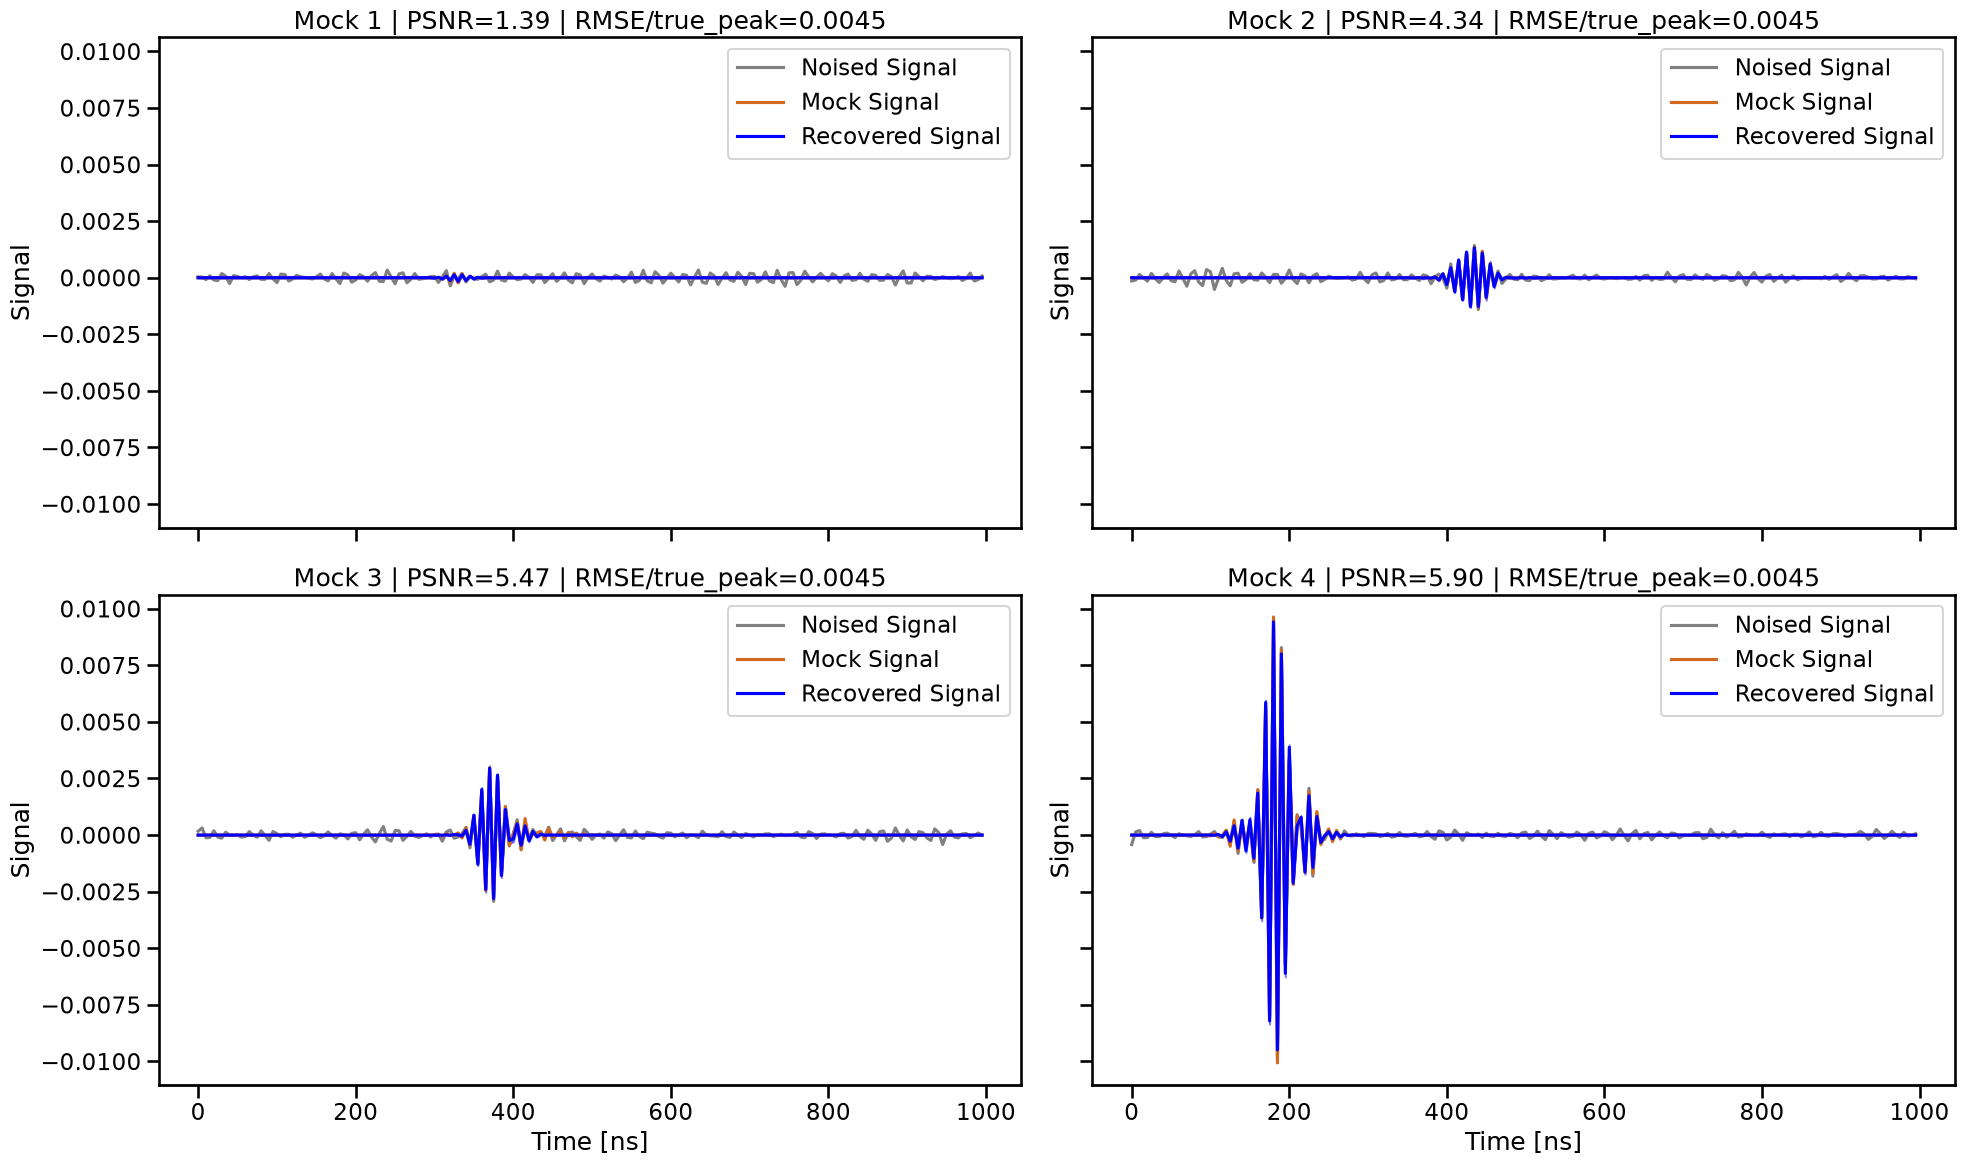

In [ ]:
# make a plot with 2x2 grid of subplots, each is the compare() function for a different index of d_true, with the title of each subplot being "Mock Signal {i+1}" where i is the index of d_true, and the x-axis label being "Time [ns]" and the y-axis label being "Signal", and save the figure as "../talk_figures/compare_signals_LOFAR.png"
sns.set_context("talk")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharex=True, sharey=True)

for i in range(4):
    y_true = d_true[i]
    y_noise = d[i]
    y_mean = means[i]
    y_std = stds[i]
    x = t200

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # first plot
    axes[i//2, i%2].plot(x, y_noise, label="Noised Signal", c="gray") # Initial data with noise
    axes[i//2, i%2].plot(x, y_true, label="Mock Signal", c="chocolate") # true signal without noise
    axes[i//2, i%2].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[i//2, i%2].plot(x, y_mean, label=f"Recovered Signal", c="blue") # Mean posterior
    
    axes[i//2, i%2].set_ylabel(r"Signal")
    axes[i//2, i%2].legend()
    axes[i//2, i%2].spines["bottom"].set_linewidth(2.0)
    axes[i//2, i%2].set_title(f"Mock {i+1} | PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")

axes[1, 0].set_xlabel("Time [ns]")
axes[1, 1].set_xlabel("Time [ns]")
axes[0, 0].set_ylabel("Signal")
axes[1, 0].set_ylabel("Signal")

plt.tight_layout()
plt.show()


#save the figure
# fig.savefig("../talk_figures/compare_signals_LOFAR.png", dpi=300)
plt.close(fig)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/4262685600.py:16: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


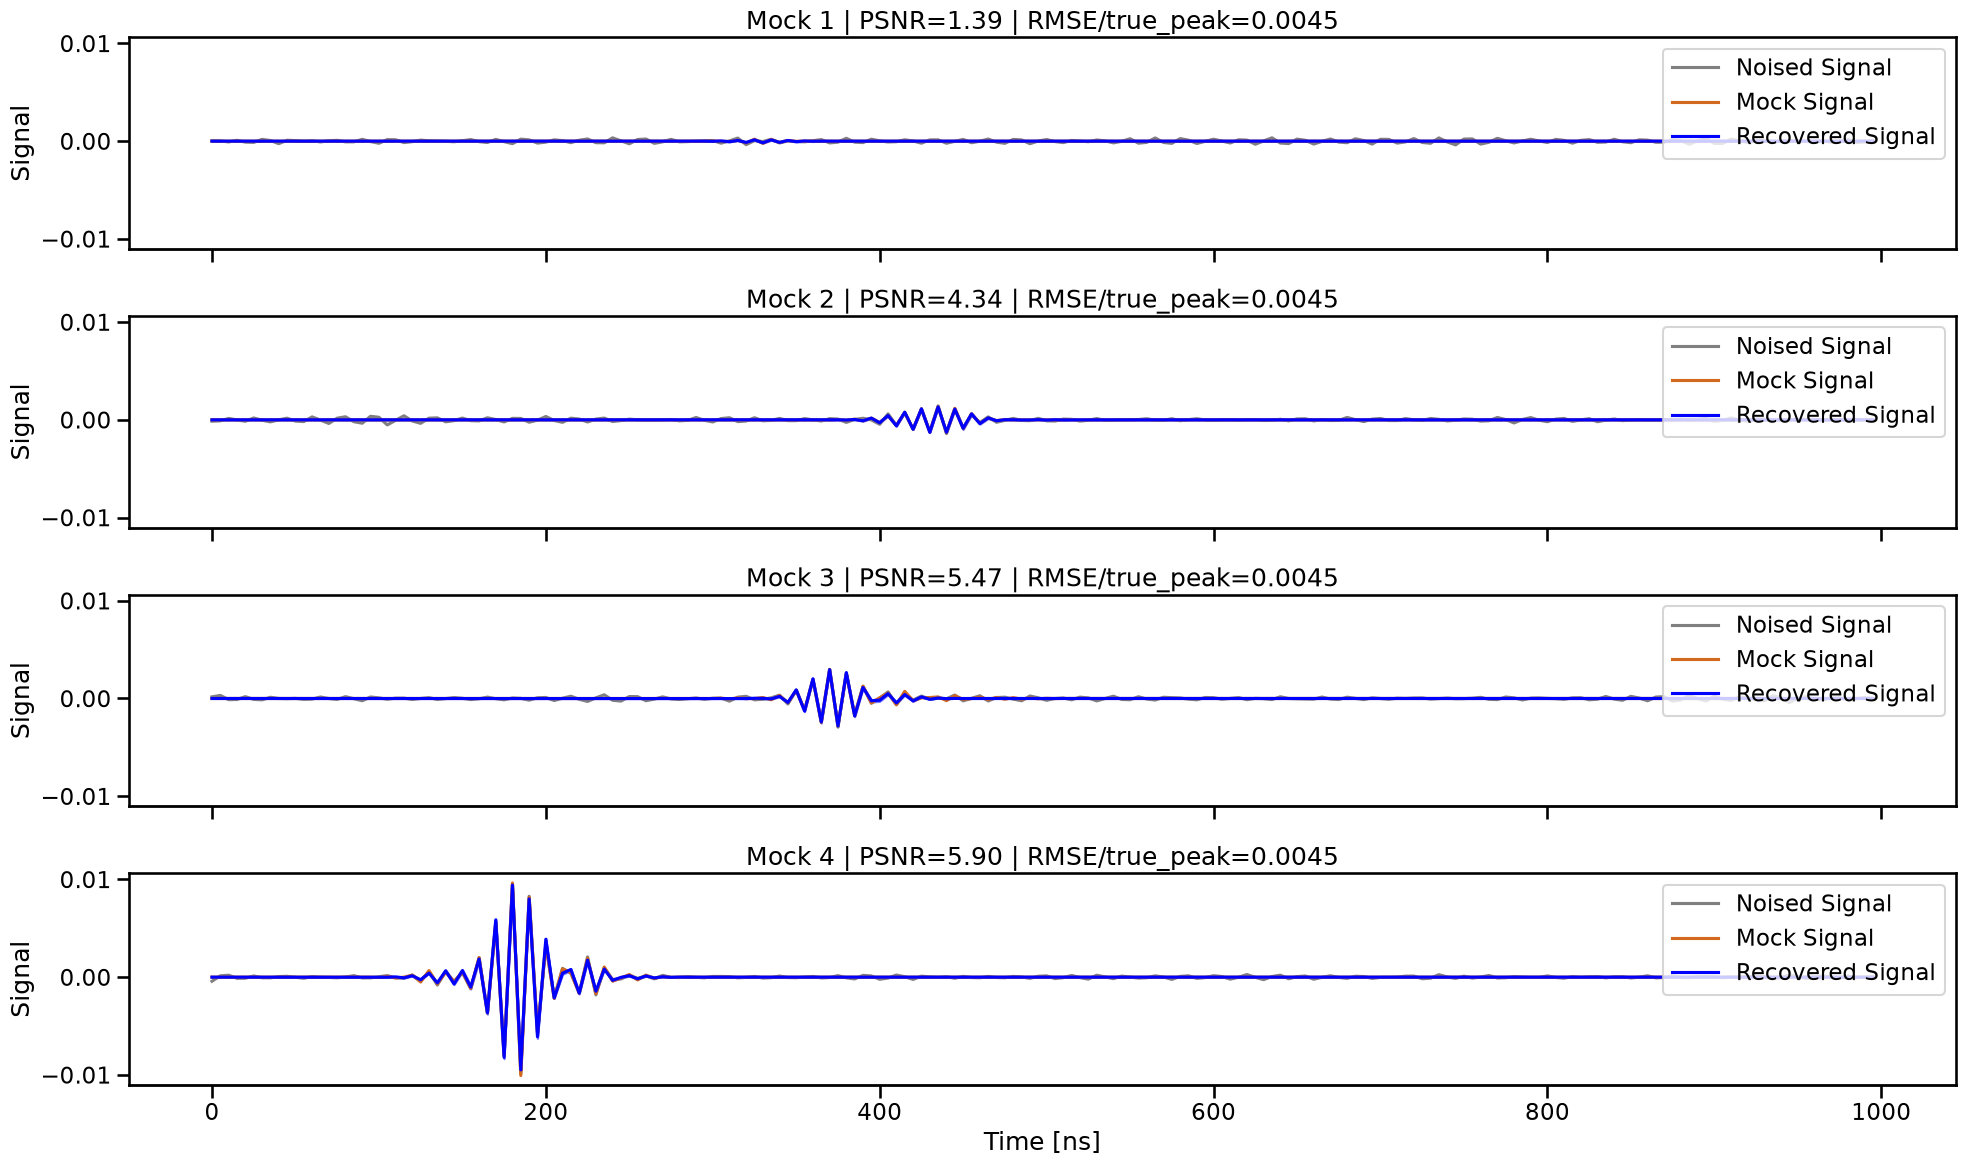

In [194]:
# make a plot with 2x2 grid of subplots, each is the compare() function for a different index of d_true, with the title of each subplot being "Mock Signal {i+1}" where i is the index of d_true, and the x-axis label being "Time [ns]" and the y-axis label being "Signal", and save the figure as "../talk_figures/compare_signals_LOFAR.png"
sns.set_context("talk")

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(20, 12), sharex=True, sharey=True)

for i in range(4):
    y_true = d_true[i]
    y_noise = d[i]
    y_mean = means[i]
    y_std = stds[i]
    x = t200

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # first plot
    axes[i].plot(x, y_noise, label="Noised Signal", c="gray") # Initial data with noise
    axes[i].plot(x, y_true, label="Mock Signal", c="chocolate") # true signal without noise
    axes[i].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[i].plot(x, y_mean, label=f"Recovered Signal", c="blue") # Mean posterior

    axes[i].set_ylabel(r"Signal")
    axes[i].legend()
    axes[i].spines["bottom"].set_linewidth(2.0)
    axes[i].set_title(f"Mock {i+1} | PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")

axes[3].set_xlabel("Time [ns]")

plt.tight_layout()
plt.show()


#save the figure
# fig.savefig("../talk_figures/compare_signals_LOFAR.png", dpi=300)
plt.close(fig)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/3829158816.py:5: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std
/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/3829158816.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


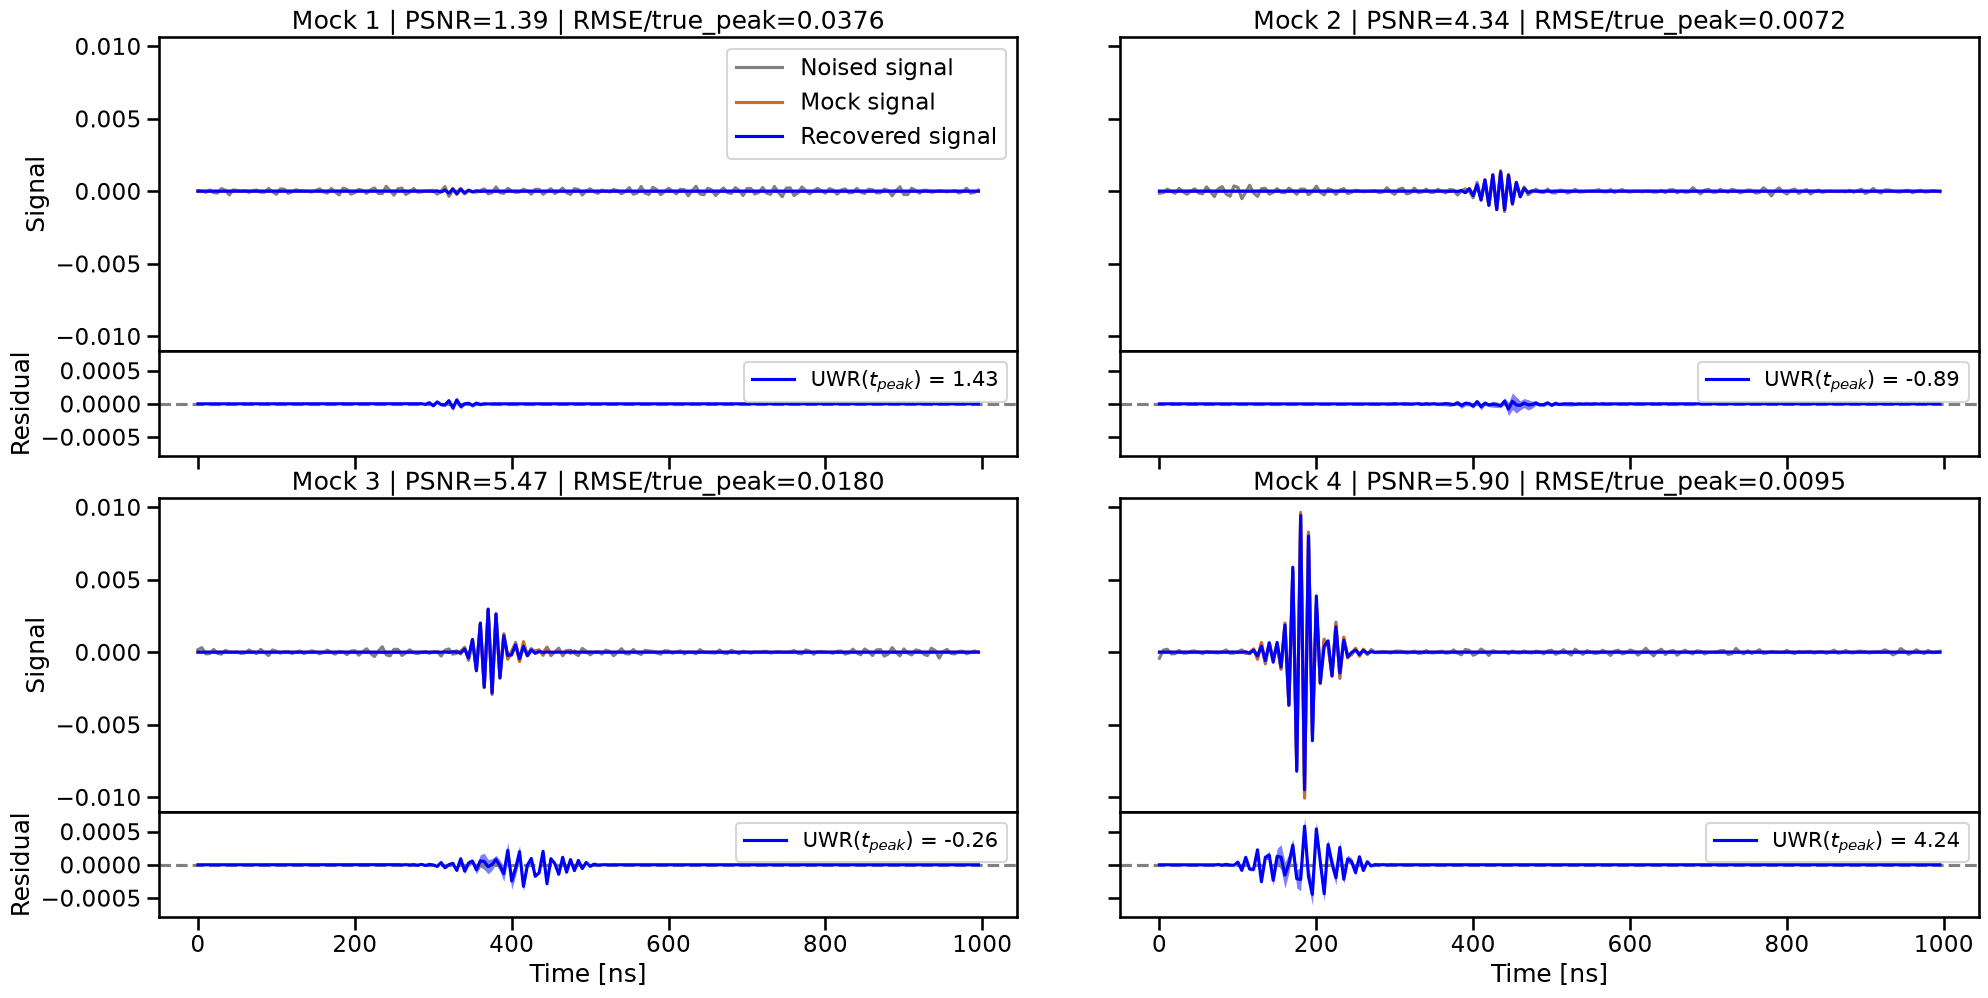

In [210]:
def plot_compare(ax_main, ax_res, x, y_true, y_noise, y_mean, y_std,
                 label_true="Mock signal", legend=True):
    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # signal panel
    ax_main.plot(x, y_noise, label="Noised signal", c="gray")
    ax_main.plot(x, y_true, label=label_true, c="chocolate")
    ax_main.fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5, lw=0)
    ax_main.plot(x, y_mean, label="Recovered signal", c="blue")
    ax_main.spines["bottom"].set_linewidth(2.0)
    if legend:
        ax_main.legend()

    # residual panel
    ax_res.axhline(0, c="gray", ls="--")
    ax_res.fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5, lw=0)
    ax_res.plot(x, diff, c="blue", label=rf"UWR($t_{{peak}}$) = {abs_res_peak:.2f}")
    ax_res.legend(loc="upper right", fontsize="small")

    return snr, diff, abs_res


sns.set_context("talk")

fig = plt.figure(figsize=(20, 10))
outer = fig.add_gridspec(2, 2, left=0.07, right=0.98, bottom=0.07, top=0.95,
                         wspace=0.12, hspace=0.1)

main_axes, res_axes, res_extent = [], [], []
for i in range(4):
    r, c = divmod(i, 2)
    inner = outer[r, c].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)

    ax_main = fig.add_subplot(inner[0],
                              sharex=main_axes[0] if main_axes else None,
                              sharey=main_axes[0] if main_axes else None)
    ax_res = fig.add_subplot(inner[1], sharex=ax_main,
                             sharey=res_axes[0] if res_axes else None)
    main_axes.append(ax_main)
    res_axes.append(ax_res)

    snr, diff, abs_res = plot_compare(ax_main, ax_res, t200, d_true[i], d[i],
                                      means[i], stds[i], legend=(i == 0))
    res_extent.append(np.max(np.abs(diff) + stds[i]))

    norm_rmse = norm_rmses[i]   # the i-th value; use whatever array holds the four
    ax_main.set_title(f"Mock {i+1} | PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")

    # tick labels and axis labels only on the outer edges
    ax_main.tick_params(labelbottom=False)
    if r == 0:
        ax_res.tick_params(labelbottom=False)
    else:
        ax_res.set_xlabel("Time [ns]")
    if c == 0:
        ax_main.set_ylabel("Signal")
        ax_res.set_ylabel("Residual")
    else:
        ax_main.tick_params(labelleft=False)
        ax_res.tick_params(labelleft=False)

# one symmetric residual range for all four, wide enough for the ±1σ band
lim = 1.1*max(res_extent)
res_axes[0].set_ylim(-lim, lim)

plt.tight_layout()

fig.savefig("../talk_figures/compare_signals_LOFAR.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/3829158816.py:5: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std
/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/1509787359.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


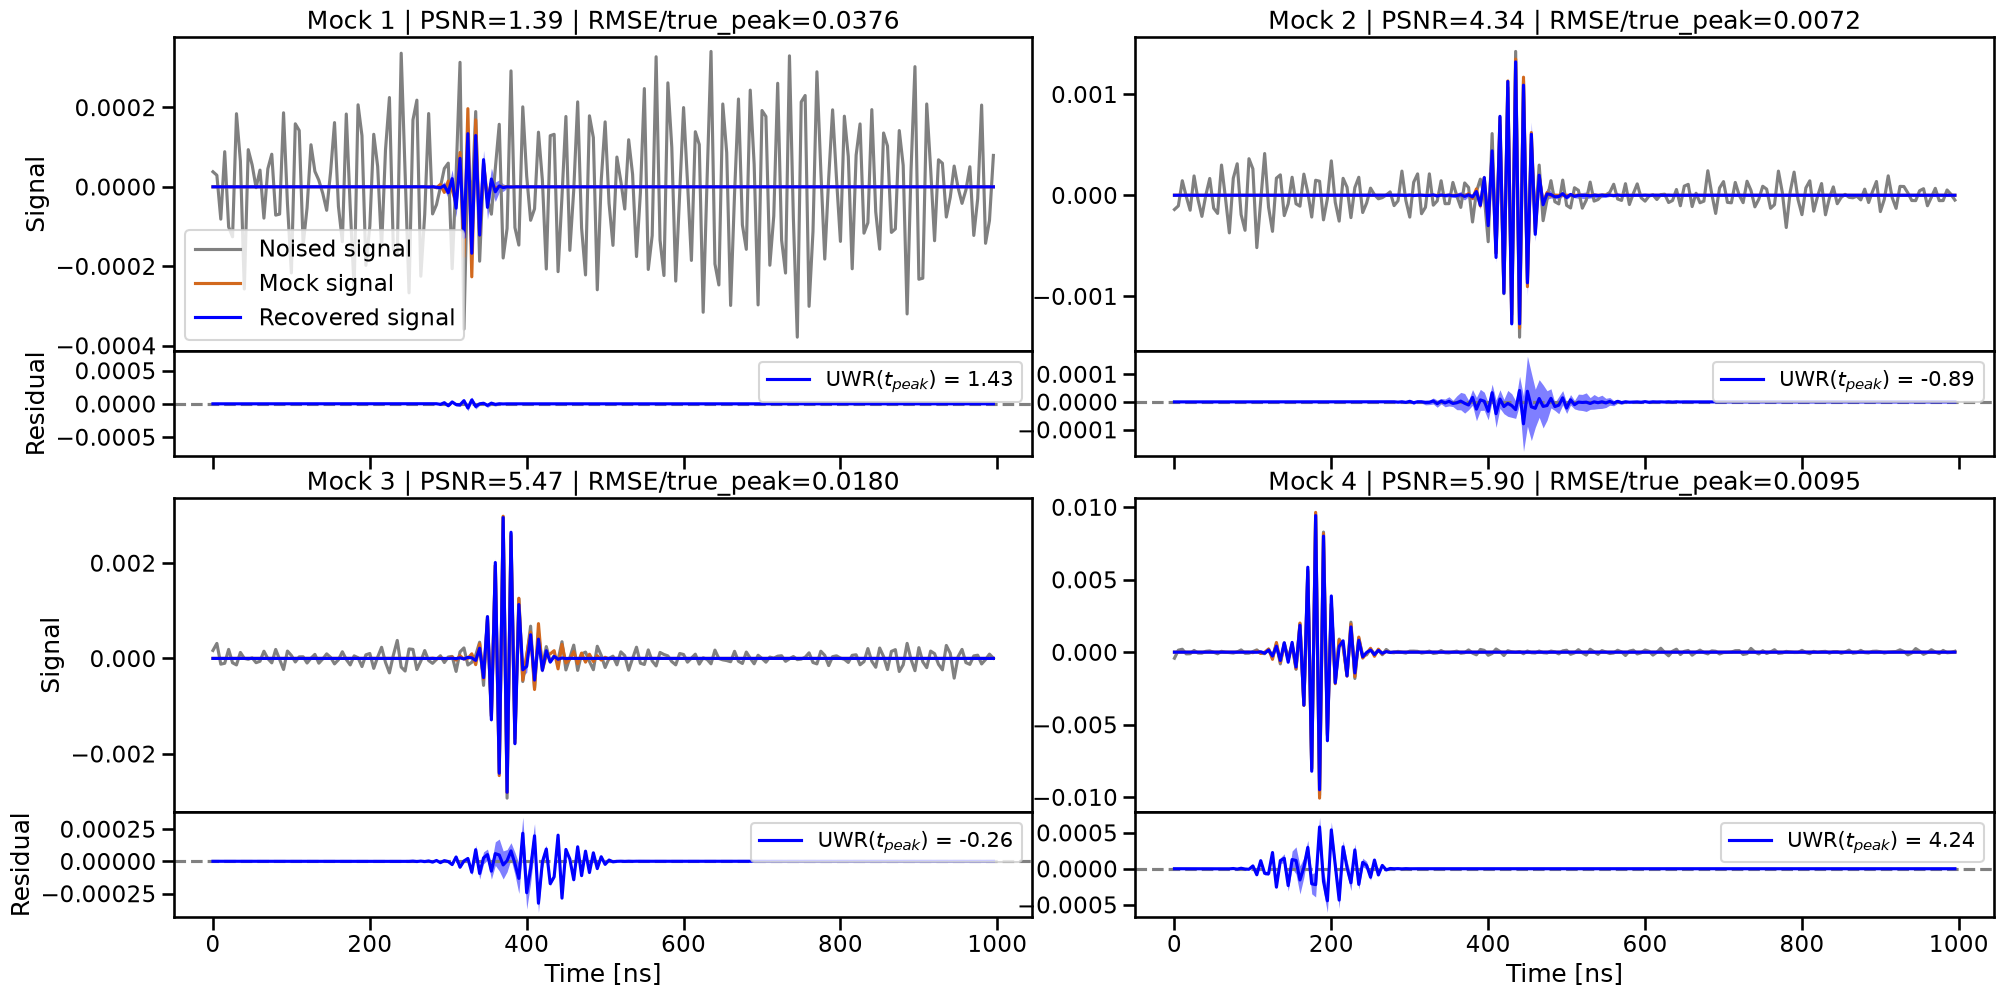

In [214]:
sns.set_context("talk")

fig = plt.figure(figsize=(20, 10))
outer = fig.add_gridspec(2, 2, left=0.07, right=0.98, bottom=0.07, top=0.95,
                         wspace=0.12, hspace=0.1)

main_axes, res_axes, res_extent = [], [], []
for i in range(4):
    r, c = divmod(i, 2)
    inner = outer[r, c].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)

    ax_main = fig.add_subplot(inner[0],
                              sharex=main_axes[0] if main_axes else None)
    ax_res = fig.add_subplot(inner[1], sharex=ax_main)
    main_axes.append(ax_main)
    res_axes.append(ax_res)

    snr, diff, abs_res = plot_compare(ax_main, ax_res, t200, d_true[i], d[i],
                                      means[i], stds[i], legend=(i == 0))
    res_extent.append(np.max(np.abs(diff) + stds[i]))

    norm_rmse = norm_rmses[i]   # the i-th value; use whatever array holds the four
    ax_main.set_title(f"Mock {i+1} | PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")

    # tick labels and axis labels only on the outer edges
    ax_main.tick_params(labelbottom=False)
    if r == 0:
        ax_res.tick_params(labelbottom=False)
    else:
        ax_res.set_xlabel("Time [ns]")
    if c == 0:
        ax_main.set_ylabel("Signal")
        ax_res.set_ylabel("Residual")
    # else:
    #     ax_main.tick_params(labelleft=False)
    #     ax_res.tick_params(labelleft=False)

# one symmetric residual range for all four, wide enough for the ±1σ band
lim = 1.1*max(res_extent)
res_axes[0].set_ylim(-lim, lim)

plt.tight_layout()

fig.savefig("../talk_figures/compare_signals_LOFAR_noSharey.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/2471058551.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


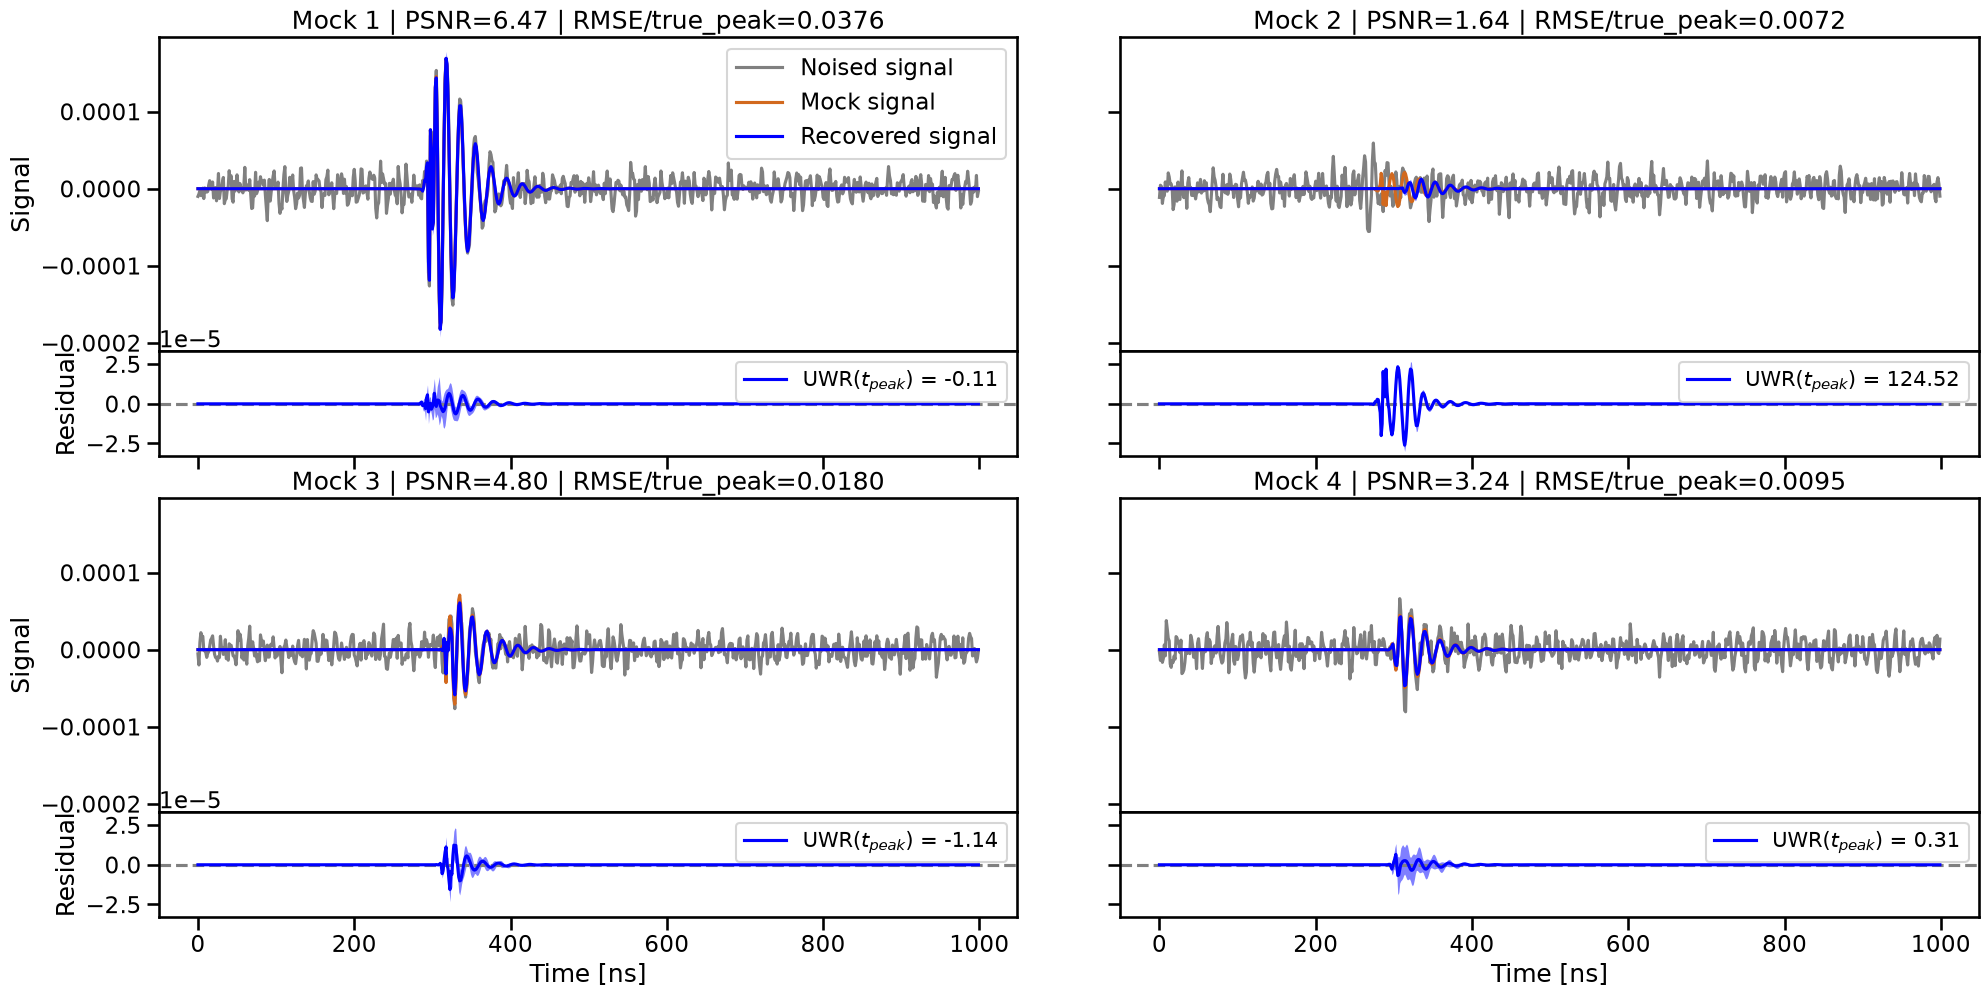

In [215]:
sns.set_context("talk")

fig = plt.figure(figsize=(20, 10))
outer = fig.add_gridspec(2, 2, left=0.07, right=0.98, bottom=0.07, top=0.95,
                         wspace=0.12, hspace=0.1)

main_axes, res_axes, res_extent = [], [], []
for i in range(4):
    r, c = divmod(i, 2)
    inner = outer[r, c].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)

    ax_main = fig.add_subplot(inner[0],
                              sharex=main_axes[0] if main_axes else None,
                              sharey=main_axes[0] if main_axes else None)
    ax_res = fig.add_subplot(inner[1], sharex=ax_main,
                             sharey=res_axes[0] if res_axes else None)
    main_axes.append(ax_main)
    res_axes.append(ax_res)

    snr, diff, abs_res = plot_compare(ax_main, ax_res, t800, ska_d_true[i], ska_d[i],
                                      ska_means[i], ska_stds[i], legend=(i == 0))
    res_extent.append(np.max(np.abs(diff) + ska_stds[i]))

    norm_rmse = norm_rmses[i]   # the i-th value; use whatever array holds the four
    ax_main.set_title(f"Mock {i+1} | PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")

    # tick labels and axis labels only on the outer edges
    ax_main.tick_params(labelbottom=False)
    if r == 0:
        ax_res.tick_params(labelbottom=False)
    else:
        ax_res.set_xlabel("Time [ns]")
    if c == 0:
        ax_main.set_ylabel("Signal")
        ax_res.set_ylabel("Residual")
    else:
        ax_main.tick_params(labelleft=False)
        ax_res.tick_params(labelleft=False)

# one symmetric residual range for all four, wide enough for the ±1σ band
lim = 1.1*max(res_extent)
res_axes[0].set_ylim(-lim, lim)

plt.tight_layout()

fig.savefig("../talk_figures/compare_signals_SKA.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/649760656.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


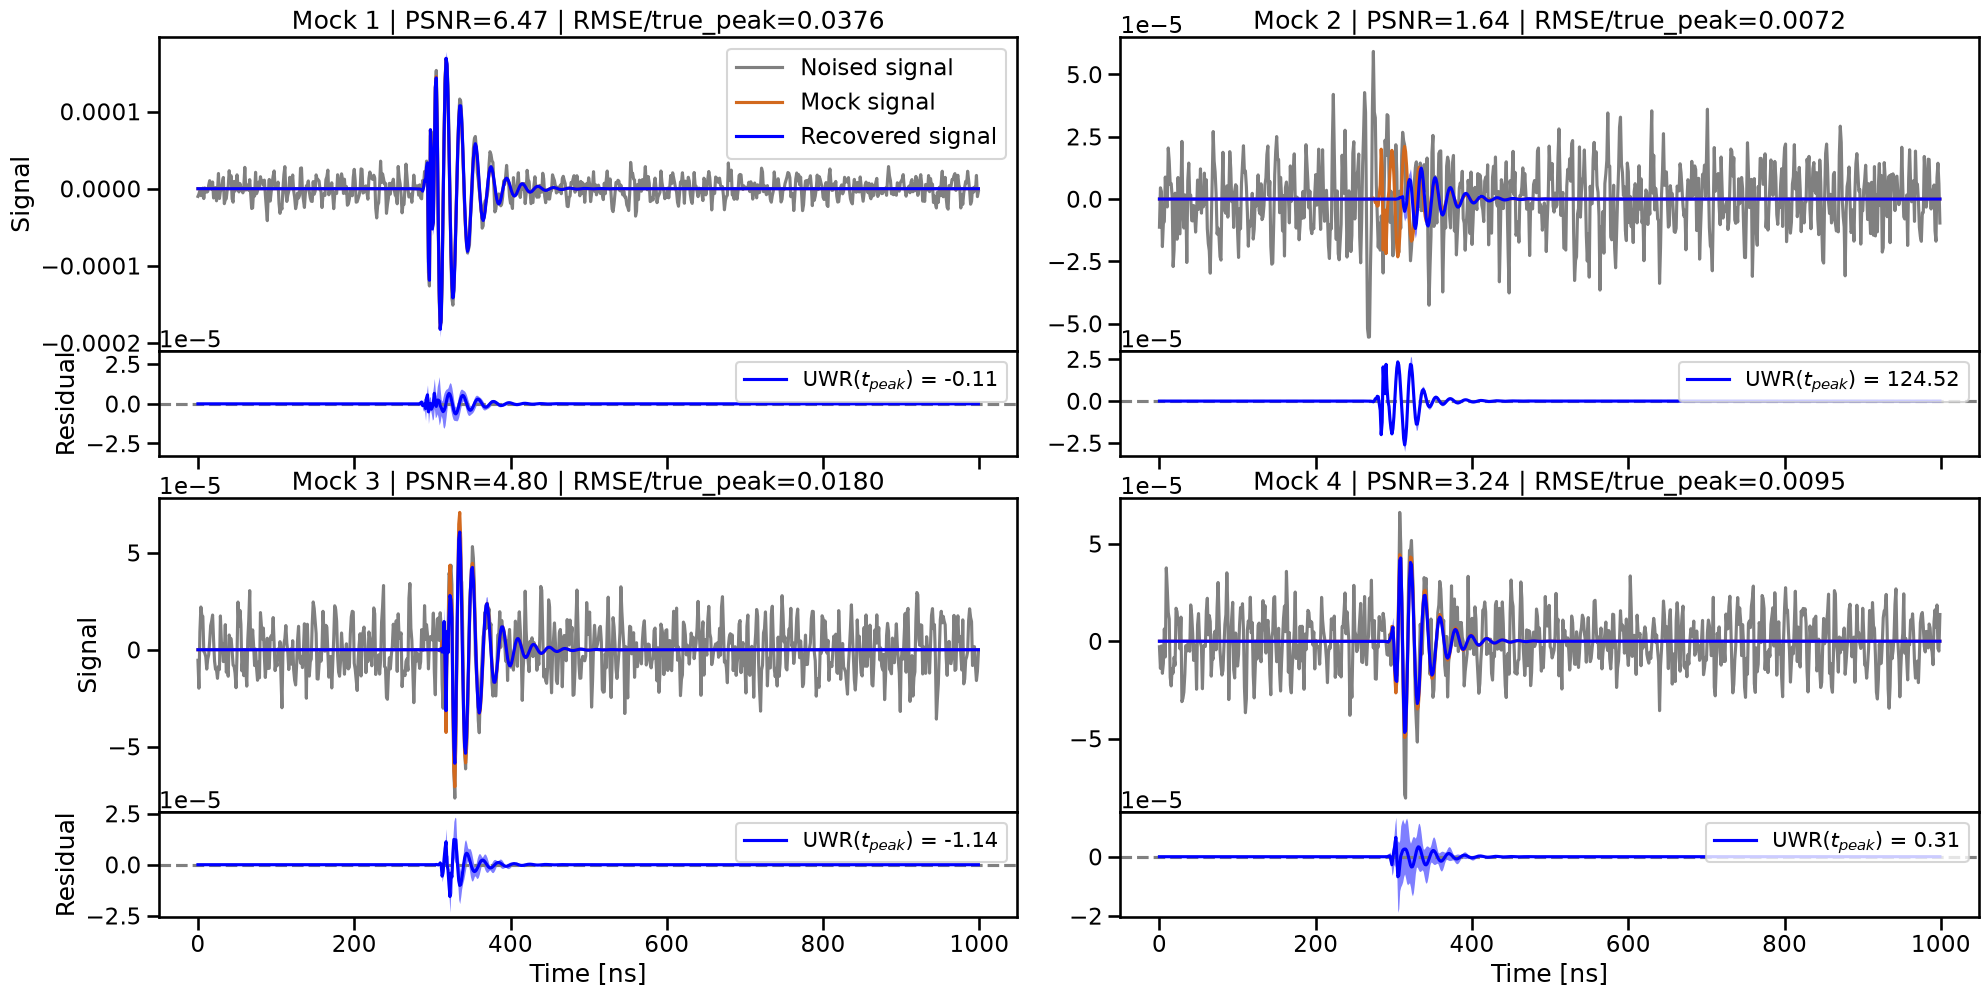

In [216]:
sns.set_context("talk")

fig = plt.figure(figsize=(20, 10))
outer = fig.add_gridspec(2, 2, left=0.07, right=0.98, bottom=0.07, top=0.95,
                         wspace=0.12, hspace=0.1)

main_axes, res_axes, res_extent = [], [], []
for i in range(4):
    r, c = divmod(i, 2)
    inner = outer[r, c].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)

    ax_main = fig.add_subplot(inner[0],
                              sharex=main_axes[0] if main_axes else None)
    ax_res = fig.add_subplot(inner[1], sharex=ax_main)
    main_axes.append(ax_main)
    res_axes.append(ax_res)

    snr, diff, abs_res = plot_compare(ax_main, ax_res, t800, ska_d_true[i], ska_d[i],
                                      ska_means[i], ska_stds[i], legend=(i == 0))
    res_extent.append(np.max(np.abs(diff) + ska_stds[i]))

    norm_rmse = norm_rmses[i]   # the i-th value; use whatever array holds the four
    ax_main.set_title(f"Mock {i+1} | PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")

    # tick labels and axis labels only on the outer edges
    ax_main.tick_params(labelbottom=False)
    if r == 0:
        ax_res.tick_params(labelbottom=False)
    else:
        ax_res.set_xlabel("Time [ns]")
    if c == 0:
        ax_main.set_ylabel("Signal")
        ax_res.set_ylabel("Residual")
    # else:
    #     ax_main.tick_params(labelleft=False)
    #     ax_res.tick_params(labelleft=False)

# one symmetric residual range for all four, wide enough for the ±1σ band
lim = 1.1*max(res_extent)
res_axes[0].set_ylim(-lim, lim)

plt.tight_layout()

fig.savefig("../talk_figures/compare_signals_SKA_noSharey.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_6023/1738862909.py:4: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


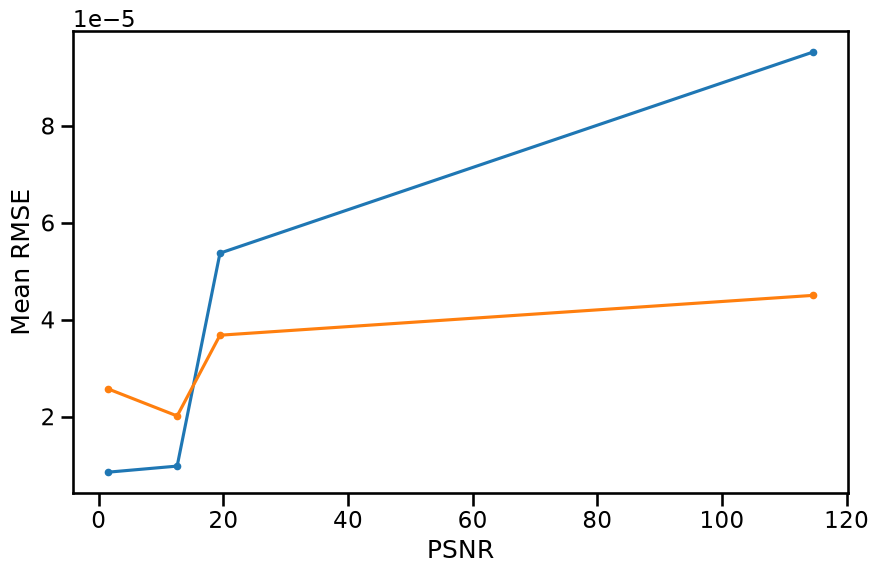

In [220]:
snr, uwr_peak = snr_uwr_peak(d_true, d, means, stds)
rmse, rmse_err = calc_RMSE_err(means, d_true, stds)

plt.figure(figsize=(10, 6))
plt.errorbar(snr, rmse, rmse_err, marker=".")
plt.errorbar(snr_diag, rmse_diag, rmse_err_diag, marker=".")
plt.xlabel("PSNR")
plt.ylabel("Mean RMSE")
plt.show()

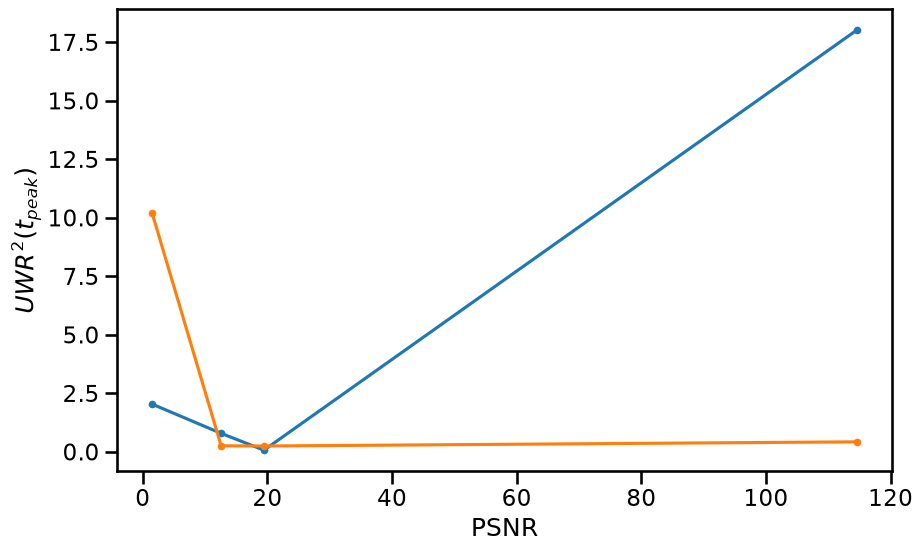

In [221]:
plt.figure(figsize=(10, 6))
plt.plot(snr, uwr_peak**2, marker=".")
plt.plot(snr_diag, uwr_peak_diag**2, marker=".")
plt.xlabel("PSNR")
plt.ylabel(r"$UWR^2(t_{peak})$")
plt.show()